In [1]:
!python --version

Python 3.12.7


In [2]:
import ema_workbench
print(ema_workbench.__version__)

2.5.3


In [3]:
from ema_workbench.connectors.vensim import VensimModel
from ema_workbench.analysis.plotting import lines, Density, kde_over_time
from ema_workbench.analysis import pairs_plotting, prim, feature_scoring, dimensional_stacking, regional_sa, get_ex_feature_scores, RuleInductionType, multiple_densities
from numpy.lib import recfunctions as rf

from ema_workbench.analysis.plotting import kde_over_time

import ema_workbench.analysis.cart as cart

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path

from ema_workbench.analysis import prim


from ema_workbench import (
    Model,
    RealParameter,
    Constant,
    ScalarOutcome,
    TimeSeriesOutcome,
    ema_logging,
    perform_experiments,
    MultiprocessingEvaluator,
    CategoricalParameter,
    save_results,
    load_results
)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection


C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\connectors\__init__.py:29: ImportWarning: netlogo connector not available
  warnings.warn("netlogo connector not available", ImportWarning)
C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\connectors\__init__.py:34: ImportWarning: simio connector not available
  warnings.warn("simio connector not available", ImportWarning)


In [4]:
path = Path("..") / "results" / "New_Modelresults6.tar.gz"
results = load_results(str(path))


In [8]:
#if pickle is used:
#import pickle
#with open('../scripts/results_backup.pkl', 'rb') as f:
#    results = pickle.load(f)

In [10]:
experiments, outcomes = results

In [11]:
pd.set_option('display.max_columns', None)
experiments

,Exogenous Healthcare level increase,Scenario Switch Healthcare scenario's,Wages on capital coefficient,Wages on technology coefficient,annual change in FTE per age due to higher wages,annual change in labour participation due to higher wages,average hiring time for new workforce,average time working at same job[Industry sector],average time working at same job[Service sector],capital on productivity coefficient,exogenous trend in capital,exogenous trend in human capital,exogenous trend in technology,exogenous trend in wages in Industry,exogenous trend in wages in Service,exogenous trend increase in Female Labour Participation,exogenous trend increase in Male Labour Participation,factor extra change in FTE per age if retired,factor extra change in labour participation if retired,female fertility rate,human capital on productivity coefficient,labour balance and wages coefficient,return to baseline of capital delay,technology on productivity coefficient,wages on productivity coefficient,wages threshold for decreasing FTE per worker,wages threshold for decreasing labour participation,Policy Switch Migration,Policy Switch Retirement age,Policy Switch Wages scenario's,scenario,policy,model
0,0.022476,1,13.621031,3.549753,0.000730,0.000863,0.694979,12.792868,6.938385,175.944727,0.006317,0.013395,0.008790,12.388734,8.418747,0.014804,0.014476,2.739679,2.414853,1.778821,3186.389798,139.186825,1.773634,3089.077766,4.293021,5857.870160,5232.929448,1,0,1,0,policy_1,LabourMarketModel
1,0.025510,1,9.945813,4.413336,0.000513,0.000739,0.659040,9.109443,6.932481,162.636814,0.007080,0.014544,0.003473,20.992526,16.703301,0.018407,0.019266,2.141993,2.485851,1.585495,2726.292603,115.850321,4.718865,3307.387608,2.104058,5910.725267,5619.918966,1,0,1,1,policy_1,LabourMarketModel
2,0.029494,1,11.628016,3.321010,0.000824,0.000613,0.190934,7.970197,7.445770,147.846021,0.006795,0.015626,0.008450,8.937158,16.217926,0.015533,0.010972,2.848692,2.809174,1.414017,3487.233769,159.047377,4.647632,2810.715366,4.381467,6140.235832,7806.559701,1,0,1,2,policy_1,LabourMarketModel
3,0.024211,2,10.837561,1.176915,0.001176,0.001878,0.299704,11.091102,6.929200,131.448380,0.008687,0.012684,0.001815,12.161365,14.550331,0.007621,0.015688,1.991160,2.289741,1.791436,2711.544273,153.927861,1.180504,2883.550444,2.501794,5106.091614,7695.191851,1,0,1,3,policy_1,LabourMarketModel
4,0.004764,1,5.486935,2.466649,0.001438,0.000854,0.564104,10.988994,11.670949,187.079173,0.005089,0.008162,0.002306,7.192486,6.631249,0.011364,0.006903,2.939299,1.846372,1.721569,2892.362884,107.703423,4.532992,2722.751042,3.753200,5230.305316,5803.185375,1,0,1,4,policy_1,LabourMarketModel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.024787,2,5.940658,3.251803,0.001162,0.001766,0.739570,10.410380,8.885075,191.646179,0.001638,0.014141,0.005957,23.855486,17.995353,0.009859,0.005113,2.522056,2.397527,1.441166,3043.258379,154.189584,3.438890,2578.300044,2.668176,5745.675092,5556.598325,5,3,2,995,policy_12,LabourMarketModel
11996,0.014735,2,8.424136,3.033799,0.001246,0.001254,0.719209,9.547737,9.658534,134.251629,0.001579,0.005865,0.001732,24.729874,16.416815,0.012282,0.006705,2.543638,2.502651,1.309804,3207.029192,131.385546,1.622884,3245.181971,3.826381,5006.399555,5989.975648,5,3,2,996,policy_12,LabourMarketModel
11997,0.009249,1,14.949462,3.456773,0.000707,0.001606,0.230053,14.299434,8.203137,132.134360,0.003857,0.012497,0.004658,12.310056,6.316710,0.011777,0.016630,1.621504,2.508938,1.589362,2610.895697,156.932747,2.233222,3474.784675,3.920215,6660.187833,5275.389037,5,3,2,997,policy_12,LabourMarketModel
11998,0.032254,1,8.773969,2.724200,0.000504,0.000852,0.201966,12.172984,11.308907,169.171943,0.005803,0.019318,0.001996,19.594860,12.610665,0.019615,0.011311,1.666864,1.988781,1.569430,2671.308138,118.290411,1.782746,2906.763940,2.692089,5743.816028,5643.256832,5,3,2,998,policy_12,LabourMarketModel


All combinations of policies are now made.

In [13]:
df_ex = experiments

unique_combinations = df_ex[
    ['Policy Switch Migration', 
     'Policy Switch Retirement age',  
     "Policy Switch Wages scenario's"]
].drop_duplicates()

print(unique_combinations)

      Policy Switch Migration Policy Switch Retirement age  \
0                           1                            0   
1000                        1                            0   
2000                        1                            3   
3000                        1                            3   
4000                        3                            0   
5000                        3                            0   
6000                        3                            3   
7000                        3                            3   
8000                        5                            0   
9000                        5                            0   
10000                       5                            3   
11000                       5                            3   

      Policy Switch Wages scenario's  
0                                  1  
1000                               2  
2000                               1  
3000                               2 

In [14]:
experiments = experiments.drop(columns=['scenario', 'policy', 'model'])

In [15]:
# Print het type van 'experiments'
print(type(experiments))

<class 'pandas.core.frame.DataFrame'>


# Validation base ensemble of population

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\2512101487.py:42: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


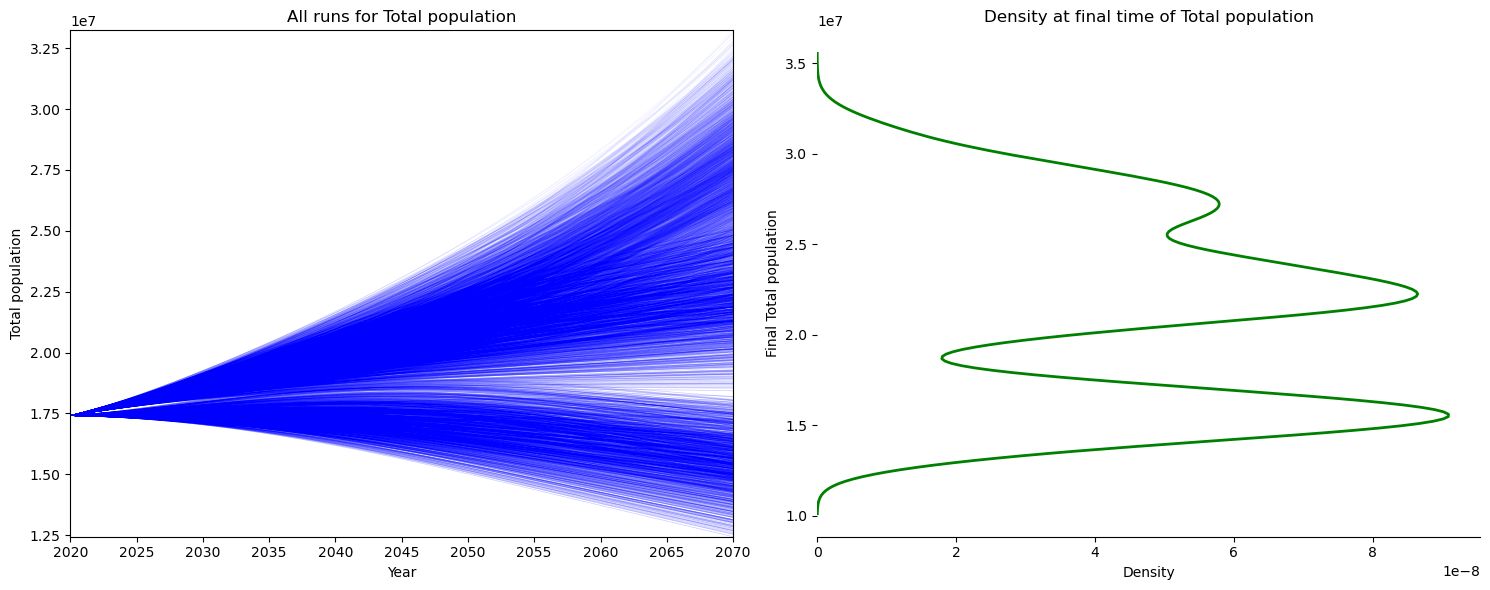

In [17]:
selected_kpi = "Total population"
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
axes[0].set_ylim(np.min(values), np.max(values))

# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'All runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi)

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi}')
sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()

# Policy performance and KDE of KPI's

Possible categorisation of uncertainties for following analysis.

In [20]:
LB_y_limit_min = -5800000
LB_y_limit_max = 400000

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\2954710689.py:44: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


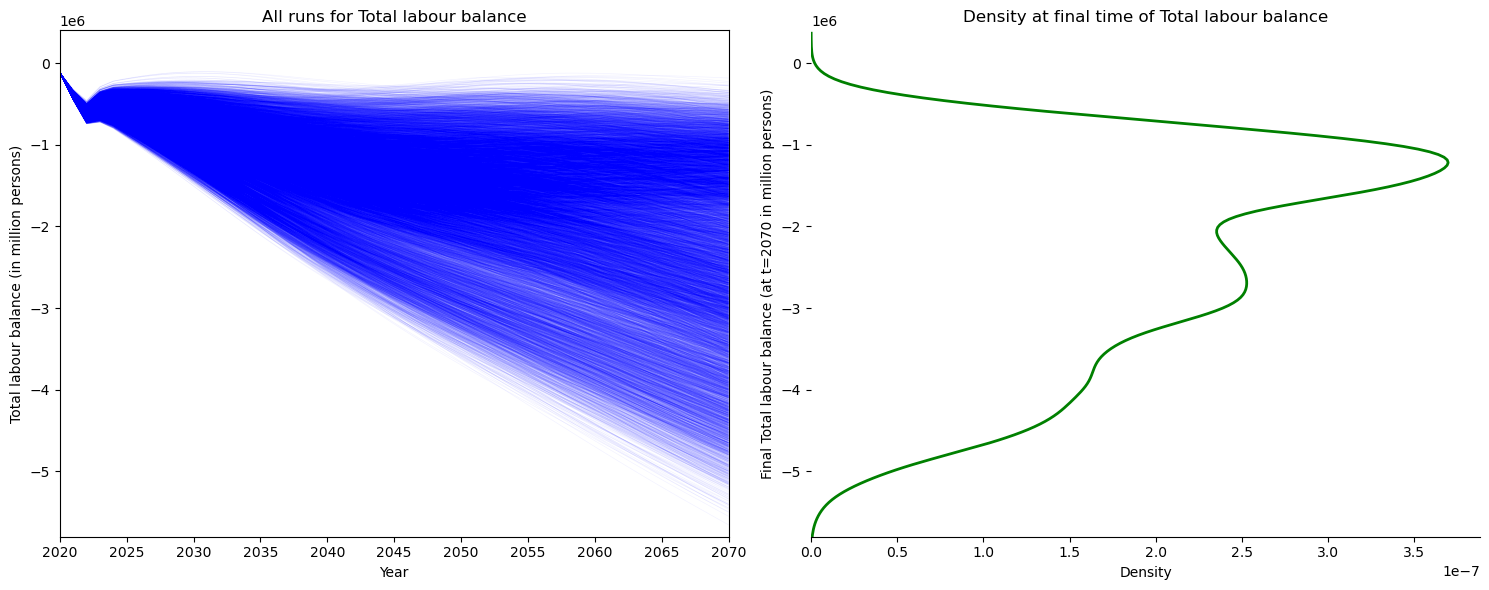

In [21]:
selected_kpi = "Total labour balance"
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
#axes[0].set_ylim(np.min(values), np.max(values))
axes[0].set_ylim(LB_y_limit_min, LB_y_limit_max) 


# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'All runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi + ' (in million persons)')

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi} (at t=2070 in million persons)' )
axes[1].set_ylim(LB_y_limit_min, LB_y_limit_max)

sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\3629564912.py:42: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


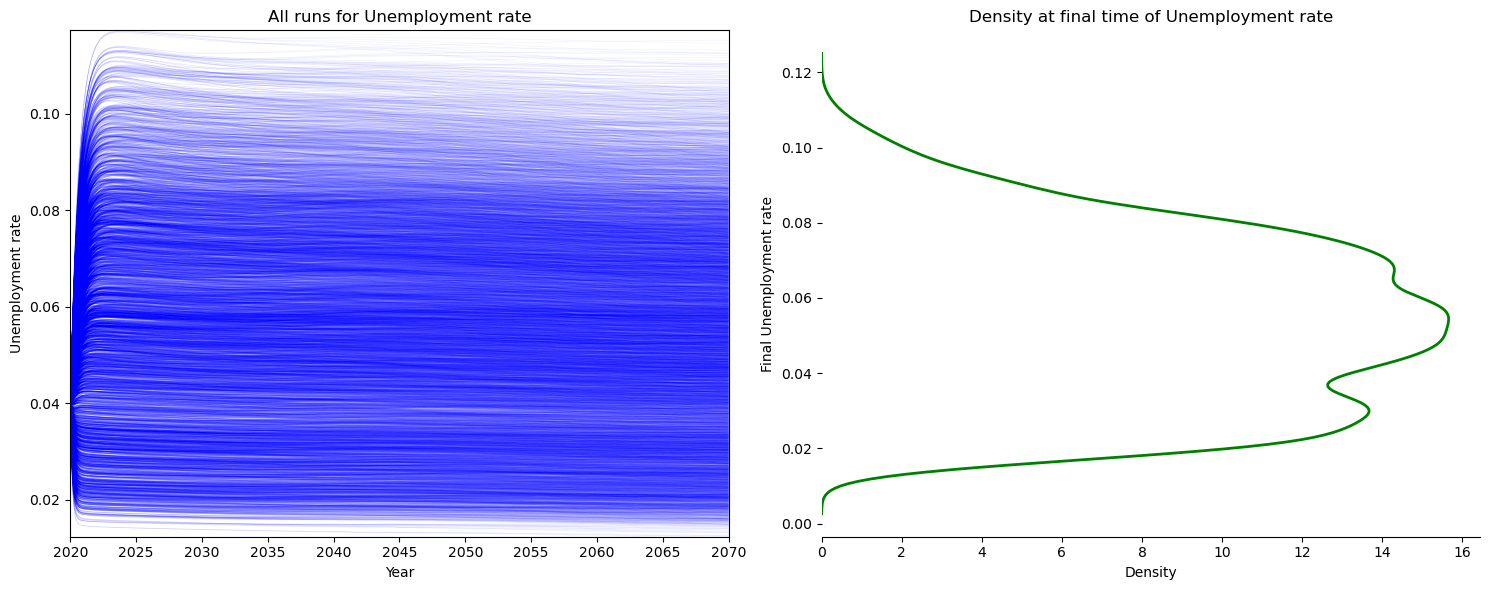

In [22]:
selected_kpi = 'Unemployment rate'
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
axes[0].set_ylim(np.min(values), np.max(values))

# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'All runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi)

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi}')
sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()


C:\Users\31628\AppData\Local\Temp\ipykernel_11672\1057256334.py:43: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


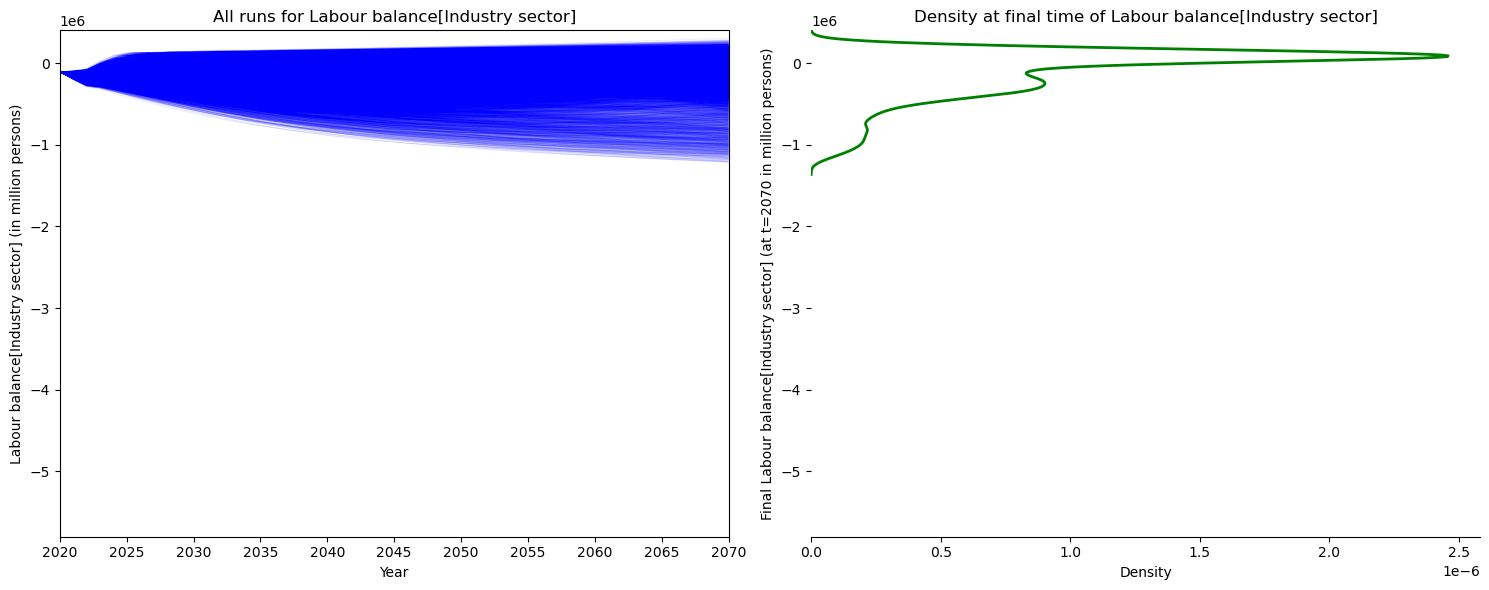

In [23]:
selected_kpi = 'Labour balance[Industry sector]'
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
#axes[0].set_ylim(np.min(values), np.max(values))
axes[0].set_ylim(LB_y_limit_min, LB_y_limit_max) 

# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'All runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi + ' (in million persons)')

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi} (at t=2070 in million persons)' )
axes[1].set_ylim(LB_y_limit_min, LB_y_limit_max)
sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()


In [24]:
LB_y_limit_min2 = -1300000
LB_y_limit_max2 = 300000

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\467471908.py:43: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


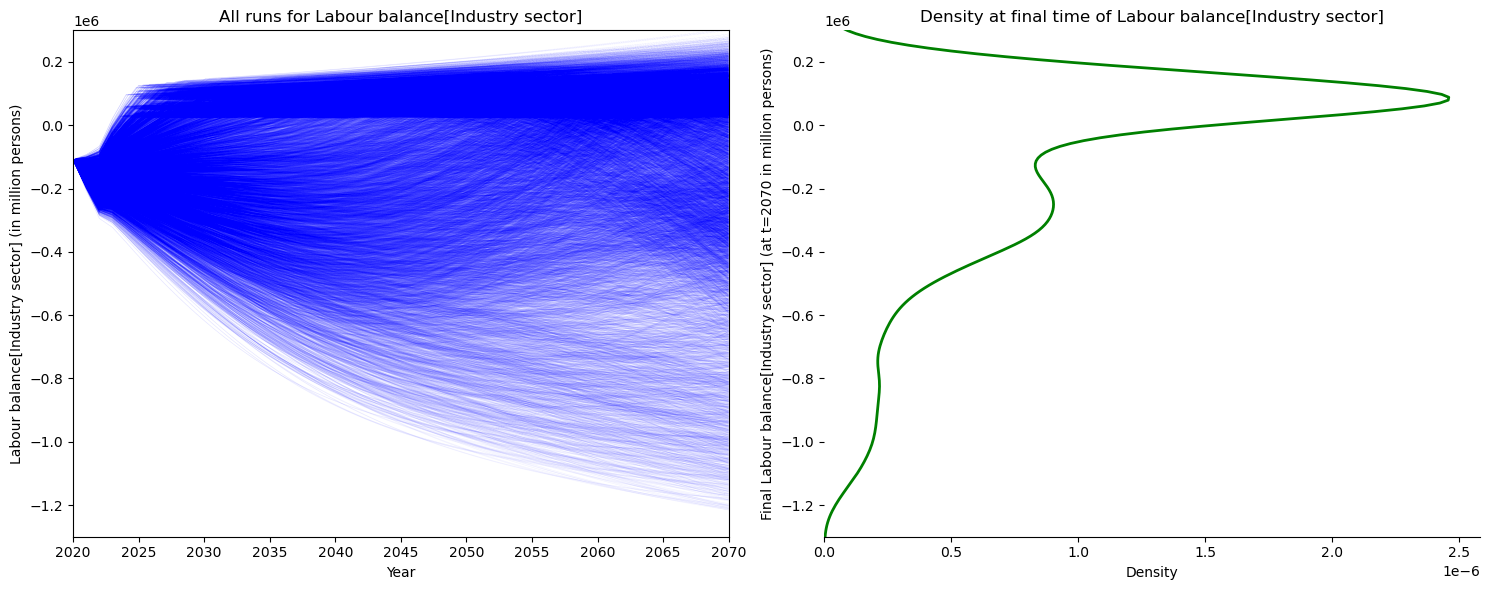

In [25]:
selected_kpi = 'Labour balance[Industry sector]'
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
#axes[0].set_ylim(np.min(values), np.max(values))
axes[0].set_ylim(LB_y_limit_min2, LB_y_limit_max2) 

# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'All runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi + ' (in million persons)')

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi} (at t=2070 in million persons)' )
axes[1].set_ylim(LB_y_limit_min2, LB_y_limit_max2)
sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()


C:\Users\31628\AppData\Local\Temp\ipykernel_11672\2511552398.py:43: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


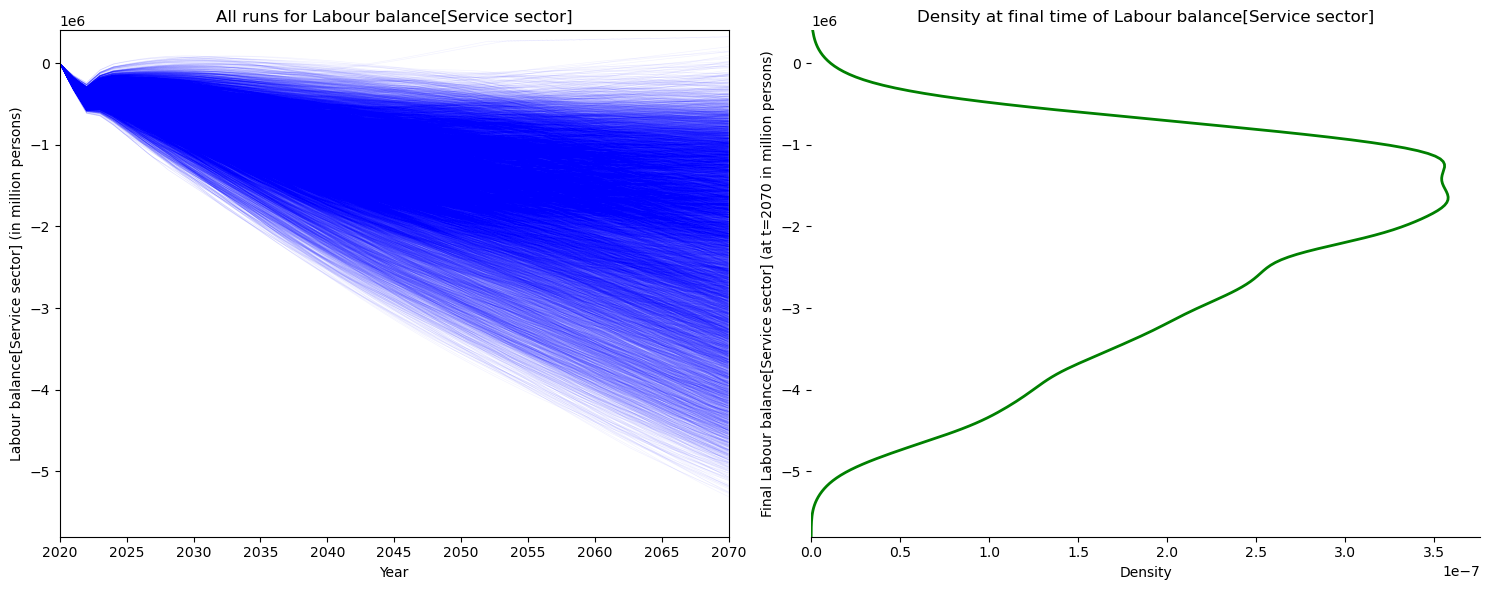

In [26]:
selected_kpi = 'Labour balance[Service sector]'
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
#axes[0].set_ylim(np.min(values), np.max(values))
axes[0].set_ylim(LB_y_limit_min, LB_y_limit_max) 

# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'All runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi + ' (in million persons)')

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi} (at t=2070 in million persons)' )
axes[1].set_ylim(LB_y_limit_min, LB_y_limit_max)
sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()


C:\Users\31628\AppData\Local\Temp\ipykernel_11672\3671622949.py:42: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


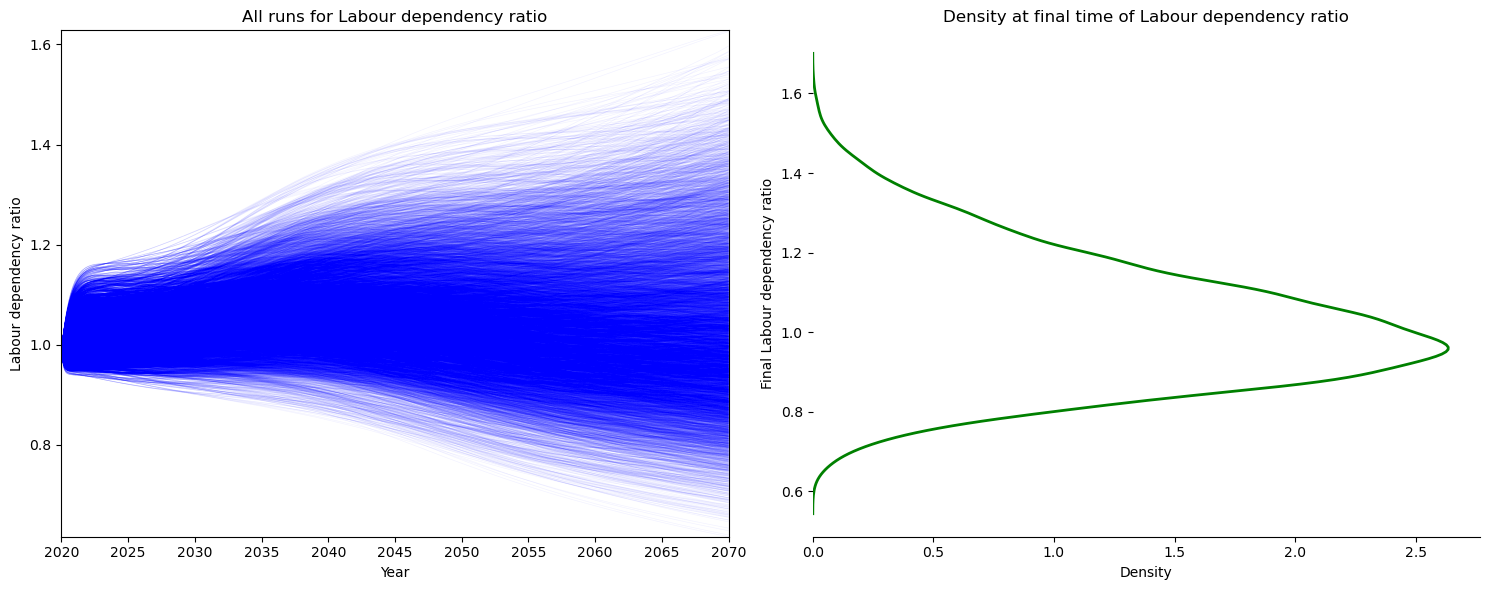

In [27]:
selected_kpi = 'Labour dependency ratio'
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
axes[0].set_ylim(np.min(values), np.max(values))

# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'All runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi)

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi}')
sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()


# Policy performance per policy

Because JupyterLab sometimes crashes when visualizing the dataset with 12000 runs, the dataset is reduced to 4000 runs for visualizations only. This reduction is applied solely for visualization purposes and does not affect analyses such as feature scoring or PRIM since for those analyses the original experiments and outcomes are used with 12000 runs. The sample from the original 12000 runs was carefully drawn using random selection without replacement, ensuring reproducibility through a fixed seed. This approach guarantees that each simulation has an equal chance of being included in the subset, preserving the overall distribution of outliers, median values, and variability similar to the full dataset. By applying the same selected indices consistently across all variables (both outcomes and experiments), the inherent relationships between different measures are maintained. As a result, the reduced dataset still captures the essential patterns and trends, minmizing the compromising ofthe representativeness of the original results.

In [30]:
original_experiments = experiments
#experiments

In [31]:
original_outcomes = outcomes
#outcomes

In [32]:
print(len(experiments))


12000


In [33]:
# Determine number of outcomes
num_runs_outcomes = next(iter(outcomes.values())).shape[0]
print(f"Number of runs in outcomes: {num_runs_outcomes}")


Number of runs in outcomes: 12000


In [34]:
for key, arr in outcomes.items():
    print(f"{key}: type={type(arr)}, shape={getattr(arr, 'shape', 'no shape')}")


TIME: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Total labour balance: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Unemployment rate: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Labour dependency ratio: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Total GDP: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Labour balance[Industry sector]: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Labour balance[Service sector]: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
GDP[Industry sector]: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
GDP[Service sector]: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Productivity per sector[Industry sector]: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Productivity per sector[Service sector]: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Wages[Industry sector]: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Wages[Service sector]: type=<class 'numpy.ndarray'>, shape=(12000, 6401)
Total population: type=<class

In [35]:
import numpy as np

# -----------------------
# Reduce all runs in 'outcomes' and 'experiments' to a representative subset

# Determine original number of runs from one of the arrays
original_num_runs = next(iter(outcomes.values())).shape[0]
target_num_runs = 4000  # desired reduced size

# Set a random seed for reproducibility
np.random.seed(42)

# Randomly select indices without replacement
selected_indices = np.random.choice(original_num_runs, size=target_num_runs, replace=False)

# Subset each array in the outcomes dictionary
outcomes = {key: arr[selected_indices] for key, arr in outcomes.items()}

# Subset experiments DataFrame, zodat het DataFrame blijft
experiments = experiments.iloc[selected_indices]

print(f"Reduced dataset from {original_num_runs} to {target_num_runs} runs.")


Reduced dataset from 12000 to 4000 runs.


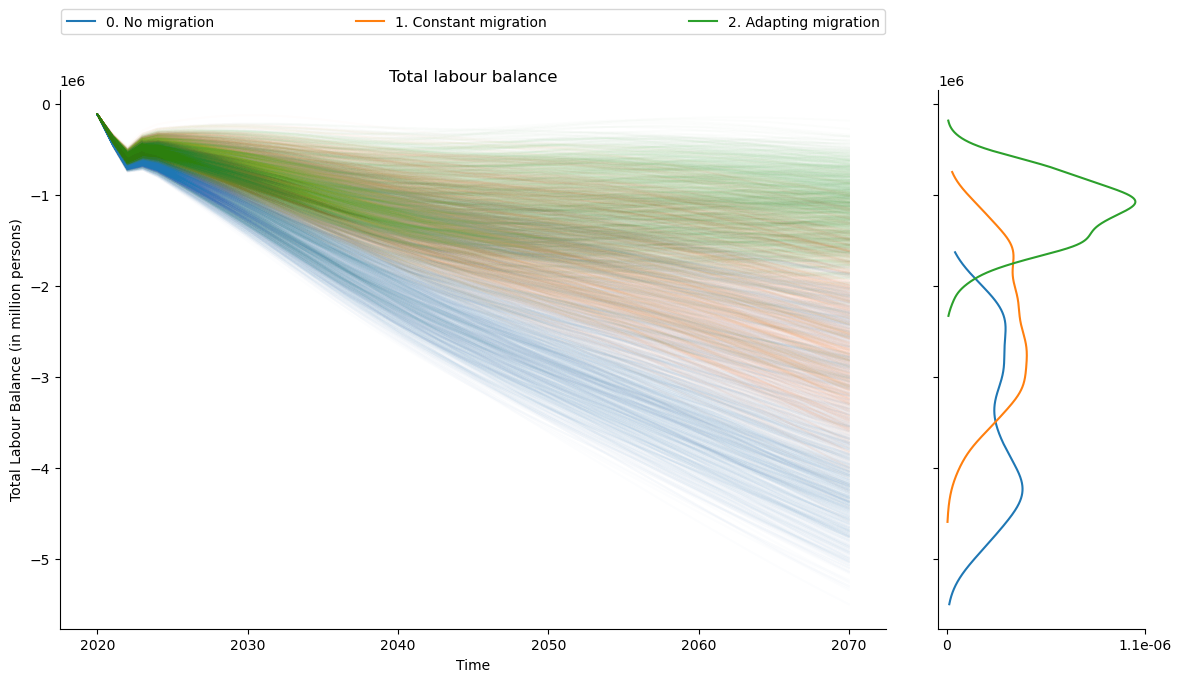

In [36]:
lines(experiments, outcomes, outcomes_to_show=['Total labour balance'],
       group_by="Policy Switch Migration", 
       grouping_specifiers={'0. No migration': 1, '1. Constant migration': 3, '2. Adapting migration': 5},
       density=Density.KDE)

fig = plt.gcf()
fig.set_size_inches(14, 7)
ax = fig.get_axes()
for line in ax[0].get_lines():
    line.set_alpha(0.01)

sns.despine()

ax[0].set_ylabel("Total Labour Balance (in million persons)")  
plt.show()


C:\Users\31628\AppData\Local\Temp\ipykernel_11672\2216353477.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


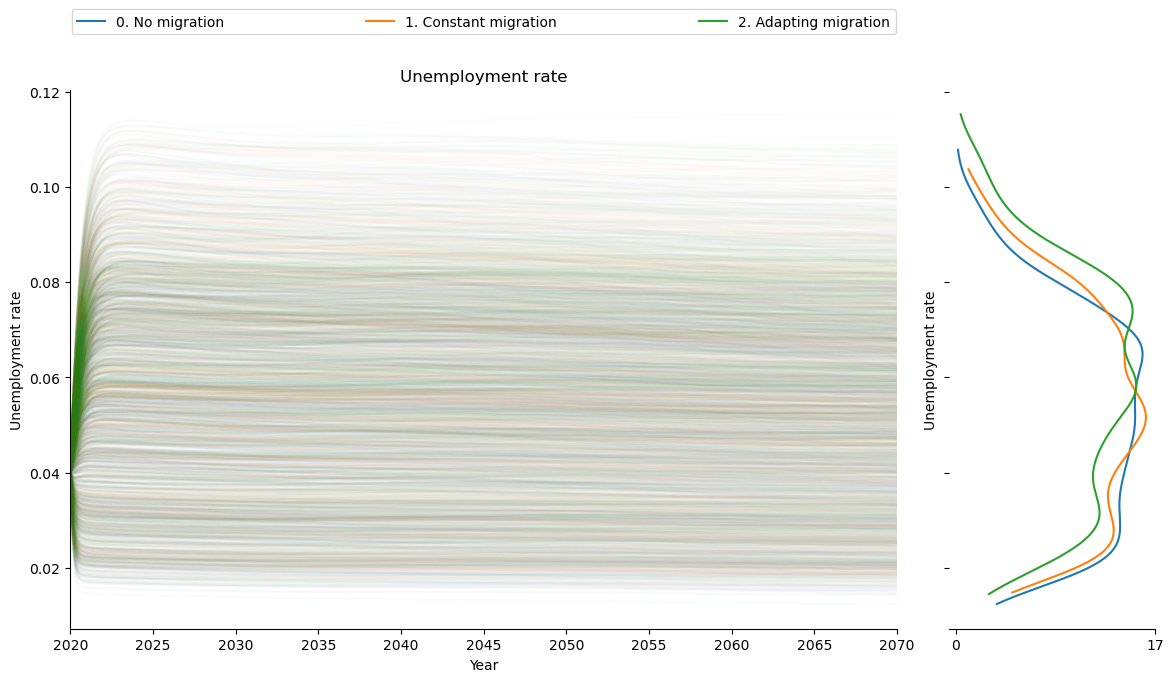

In [37]:
# 1. Plot lines and end-state density
lines(
    experiments,
    outcomes,
    outcomes_to_show=['Unemployment rate'],
    group_by="Policy Switch Migration",
    grouping_specifiers = {'0. No migration' : 1, '1. Constant migration' : 3, '2. Adapting migration' : 5},
    density=Density.KDE
)

# -----------------------
# 2. Resize the figure
fig = plt.gcf()
fig.set_size_inches(14, 7)
ax = fig.get_axes()

# -----------------------
# 3. Make individual lines very transparent
for line in ax[0].get_lines():
    line.set_alpha(0.01)

# -----------------------
# 4. Rebuild the time axis from 2020 to 2070

# Grab the x-data from one of the lines (should be real years)
line = ax[0].get_lines()[0]
x_data = line.get_xdata()

# Force the full range on the x-axis
xmin, xmax = x_data.min(), x_data.max()
ax[0].set_xlim(xmin, xmax)

# Compute ticks every 5 years
year_ticks = np.arange(2020, 2071, 5)
# Only keep those within the data range
year_ticks = year_ticks[(year_ticks >= xmin) & (year_ticks <= xmax)]

ax[0].set_xticks(year_ticks)
ax[0].set_xticklabels(year_ticks)
ax[0].set_xlabel('Year')

# -----------------------
# 5. Clean up the right panel
if len(ax) > 1:
    ax[1].set_ylabel('Unemployment rate')  # if you want to relabel
    sns.despine(ax=ax[1], left=True)

# -----------------------
# 6. Despine the left panel and adjust layout
sns.despine(ax=ax[0])
try:
    fig.tight_layout()
except:
    # fallback if tight_layout fails
    fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.15, wspace=0.3)

plt.show()


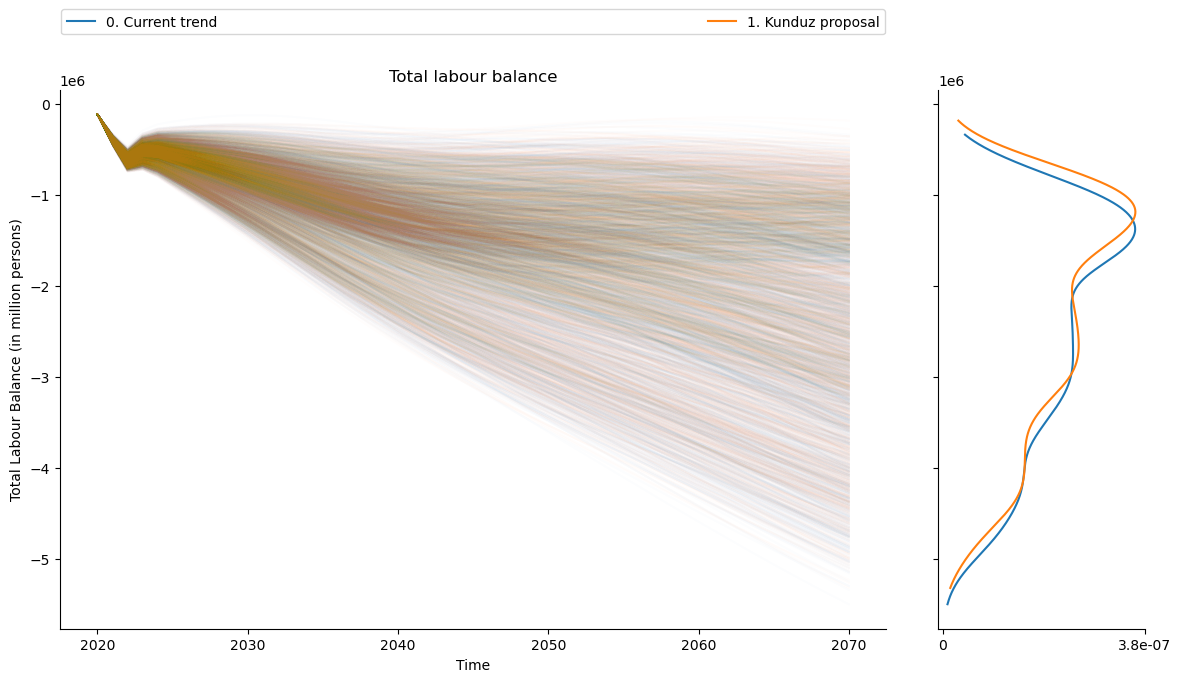

In [38]:
lines(experiments, outcomes, outcomes_to_show=['Total labour balance'],
               group_by= "Policy Switch Retirement age", 
               grouping_specifiers = {'0. Current trend' : 0, '1. Kunduz proposal' : 3}
              # 'Current trend' : 0,
               , density = Density.KDE) #show lines, and end state density

fig = plt.gcf()
fig.set_size_inches(14,7)
ax = fig.get_axes()
for line in ax[0].get_lines():
    line.set_alpha(0.01)
sns.despine()

ax[0].set_ylabel("Total Labour Balance (in million persons)")  
plt.show() #show figure

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\3671254827.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


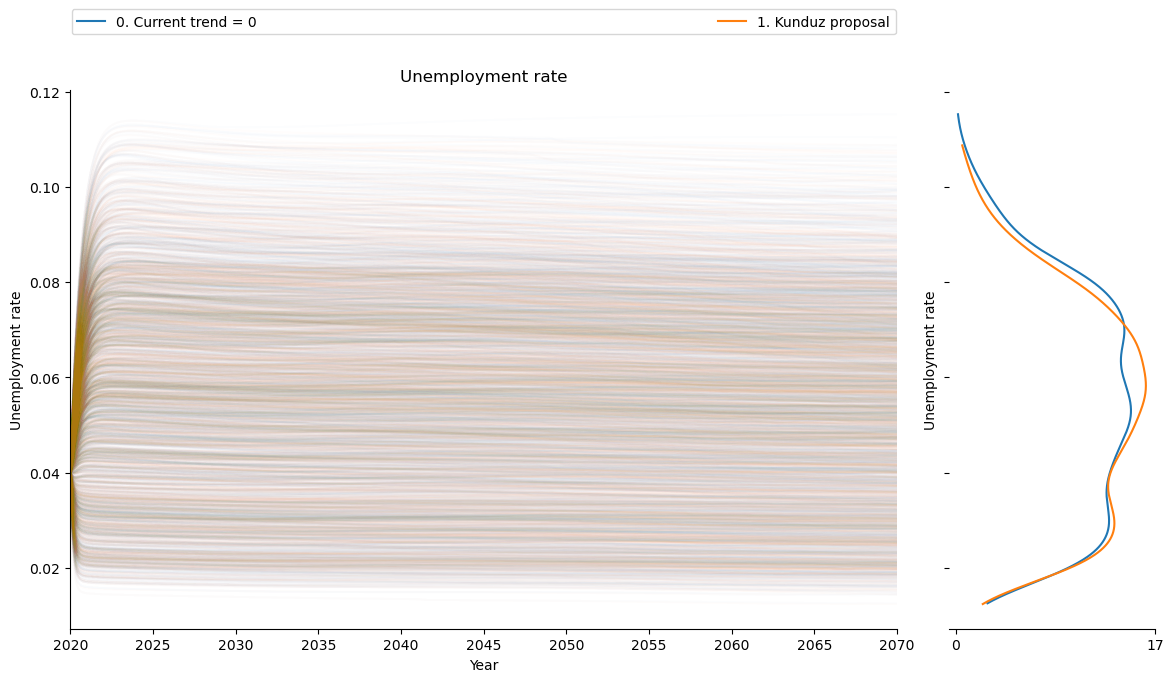

In [39]:
# 1. Plot lines and end-state density
lines(
    experiments,
    outcomes,
    outcomes_to_show=['Unemployment rate'],
    group_by="Policy Switch Retirement age",
    grouping_specifiers = {'0. Current trend = 0' : 0, '1. Kunduz proposal' : 3},
    density=Density.KDE
    )

# -----------------------
# 2. Resize the figure
fig = plt.gcf()
fig.set_size_inches(14, 7)
ax = fig.get_axes()

# -----------------------
# 3. Make individual lines very transparent
for line in ax[0].get_lines():
    line.set_alpha(0.01)

# -----------------------
# 4. Rebuild the time axis from 2020 to 2070

# Grab the x-data from one of the lines (should be real years)
line = ax[0].get_lines()[0]
x_data = line.get_xdata()

# Force the full range on the x-axis
xmin, xmax = x_data.min(), x_data.max()
ax[0].set_xlim(xmin, xmax)

# Compute ticks every 5 years
year_ticks = np.arange(2020, 2071, 5)
# Only keep those within the data range
year_ticks = year_ticks[(year_ticks >= xmin) & (year_ticks <= xmax)]

ax[0].set_xticks(year_ticks)
ax[0].set_xticklabels(year_ticks)
ax[0].set_xlabel('Year')

# -----------------------
# 5. Clean up the right panel
if len(ax) > 1:
    ax[1].set_ylabel('Unemployment rate')  # if you want to relabel
    sns.despine(ax=ax[1], left=True)

# -----------------------
# 6. Despine the left panel and adjust layout
sns.despine(ax=ax[0])
try:
    fig.tight_layout()
except:
    # fallback if tight_layout fails
    fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.15, wspace=0.3)

plt.show()


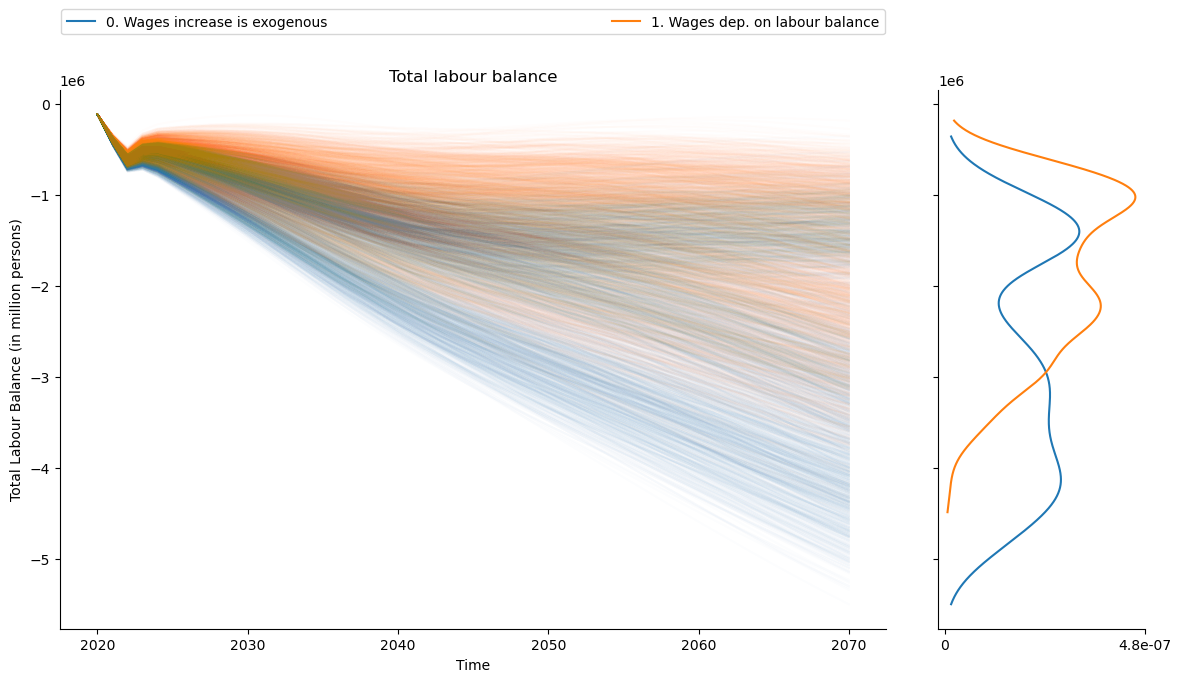

In [40]:
lines(experiments, outcomes, outcomes_to_show=['Total labour balance'],
               group_by= "Policy Switch Wages scenario's", 
               grouping_specifiers = {'0. Wages increase is exogenous' : 1, '1. Wages dep. on labour balance' : 2}
              # 'Current trend' : 0,
               , density = Density.KDE) #show lines, and end state density

fig = plt.gcf()
fig.set_size_inches(14,7)
ax = fig.get_axes()
for line in ax[0].get_lines():
    line.set_alpha(0.01)
sns.despine()

ax[0].set_ylabel("Total Labour Balance (in million persons)")  
plt.show() #show figure

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\355331798.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


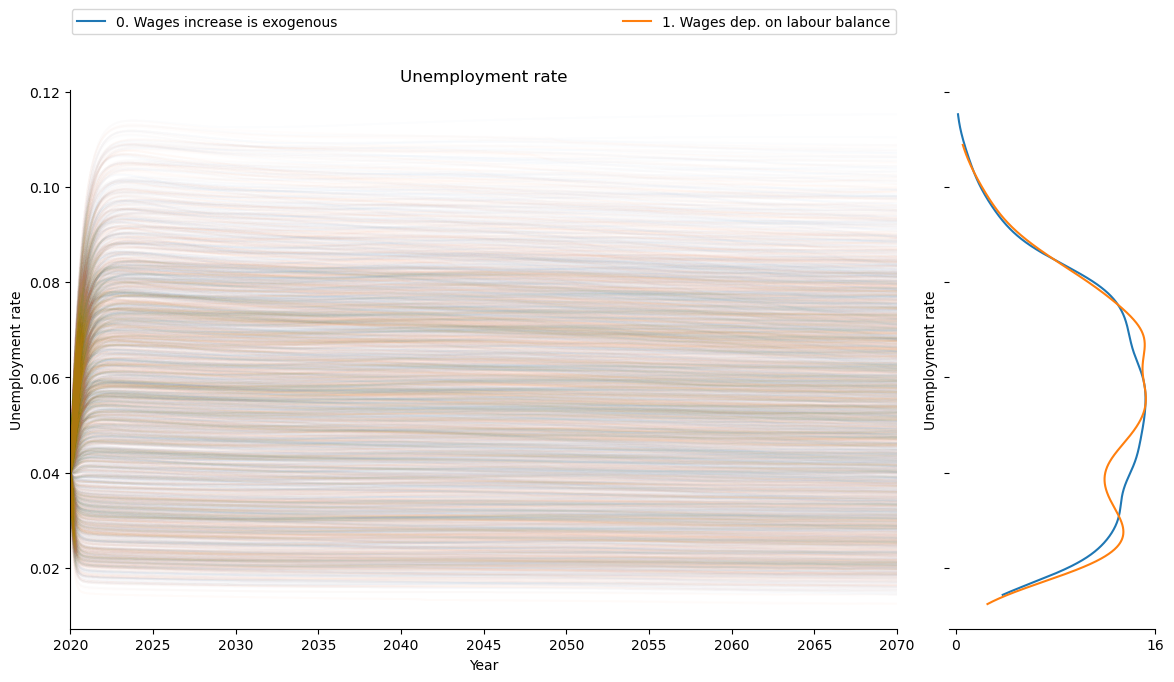

In [41]:
# 1. Plot lines and end-state density
lines(
    experiments,
    outcomes,
    outcomes_to_show=['Unemployment rate'],
    group_by= "Policy Switch Wages scenario's", 
               grouping_specifiers = {'0. Wages increase is exogenous' : 1, '1. Wages dep. on labour balance' : 2},
    density=Density.KDE
    )

# -----------------------
# 2. Resize the figure
fig = plt.gcf()
fig.set_size_inches(14, 7)
ax = fig.get_axes()

# -----------------------
# 3. Make individual lines very transparent
for line in ax[0].get_lines():
    line.set_alpha(0.01)

# -----------------------
# 4. Rebuild the time axis from 2020 to 2070

# Grab the x-data from one of the lines (should be real years)
line = ax[0].get_lines()[0]
x_data = line.get_xdata()

# Force the full range on the x-axis
xmin, xmax = x_data.min(), x_data.max()
ax[0].set_xlim(xmin, xmax)

# Compute ticks every 5 years
year_ticks = np.arange(2020, 2071, 5)
# Only keep those within the data range
year_ticks = year_ticks[(year_ticks >= xmin) & (year_ticks <= xmax)]

ax[0].set_xticks(year_ticks)
ax[0].set_xticklabels(year_ticks)
ax[0].set_xlabel('Year')

# -----------------------
# 5. Clean up the right panel
if len(ax) > 1:
    ax[1].set_ylabel('Unemployment rate')  # if you want to relabel
    sns.despine(ax=ax[1], left=True)

# -----------------------
# 6. Despine the left panel and adjust layout
sns.despine(ax=ax[0])
try:
    fig.tight_layout()
except:
    # fallback if tight_layout fails
    fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.15, wspace=0.3)

plt.show()


# Feature scoring

Note that now, during analysis, the original outcomes and experiments with 12000 runs are used in stead of the modified dataset with 4000 runs that was used for the visualisations above.

In [44]:
#original_outcomes
original_experiments

,Exogenous Healthcare level increase,Scenario Switch Healthcare scenario's,Wages on capital coefficient,Wages on technology coefficient,annual change in FTE per age due to higher wages,annual change in labour participation due to higher wages,average hiring time for new workforce,average time working at same job[Industry sector],average time working at same job[Service sector],capital on productivity coefficient,exogenous trend in capital,exogenous trend in human capital,exogenous trend in technology,exogenous trend in wages in Industry,exogenous trend in wages in Service,exogenous trend increase in Female Labour Participation,exogenous trend increase in Male Labour Participation,factor extra change in FTE per age if retired,factor extra change in labour participation if retired,female fertility rate,human capital on productivity coefficient,labour balance and wages coefficient,return to baseline of capital delay,technology on productivity coefficient,wages on productivity coefficient,wages threshold for decreasing FTE per worker,wages threshold for decreasing labour participation,Policy Switch Migration,Policy Switch Retirement age,Policy Switch Wages scenario's
0,0.022476,1,13.621031,3.549753,0.000730,0.000863,0.694979,12.792868,6.938385,175.944727,0.006317,0.013395,0.008790,12.388734,8.418747,0.014804,0.014476,2.739679,2.414853,1.778821,3186.389798,139.186825,1.773634,3089.077766,4.293021,5857.870160,5232.929448,1,0,1
1,0.025510,1,9.945813,4.413336,0.000513,0.000739,0.659040,9.109443,6.932481,162.636814,0.007080,0.014544,0.003473,20.992526,16.703301,0.018407,0.019266,2.141993,2.485851,1.585495,2726.292603,115.850321,4.718865,3307.387608,2.104058,5910.725267,5619.918966,1,0,1
2,0.029494,1,11.628016,3.321010,0.000824,0.000613,0.190934,7.970197,7.445770,147.846021,0.006795,0.015626,0.008450,8.937158,16.217926,0.015533,0.010972,2.848692,2.809174,1.414017,3487.233769,159.047377,4.647632,2810.715366,4.381467,6140.235832,7806.559701,1,0,1
3,0.024211,2,10.837561,1.176915,0.001176,0.001878,0.299704,11.091102,6.929200,131.448380,0.008687,0.012684,0.001815,12.161365,14.550331,0.007621,0.015688,1.991160,2.289741,1.791436,2711.544273,153.927861,1.180504,2883.550444,2.501794,5106.091614,7695.191851,1,0,1
4,0.004764,1,5.486935,2.466649,0.001438,0.000854,0.564104,10.988994,11.670949,187.079173,0.005089,0.008162,0.002306,7.192486,6.631249,0.011364,0.006903,2.939299,1.846372,1.721569,2892.362884,107.703423,4.532992,2722.751042,3.753200,5230.305316,5803.185375,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.024787,2,5.940658,3.251803,0.001162,0.001766,0.739570,10.410380,8.885075,191.646179,0.001638,0.014141,0.005957,23.855486,17.995353,0.009859,0.005113,2.522056,2.397527,1.441166,3043.258379,154.189584,3.438890,2578.300044,2.668176,5745.675092,5556.598325,5,3,2
11996,0.014735,2,8.424136,3.033799,0.001246,0.001254,0.719209,9.547737,9.658534,134.251629,0.001579,0.005865,0.001732,24.729874,16.416815,0.012282,0.006705,2.543638,2.502651,1.309804,3207.029192,131.385546,1.622884,3245.181971,3.826381,5006.399555,5989.975648,5,3,2
11997,0.009249,1,14.949462,3.456773,0.000707,0.001606,0.230053,14.299434,8.203137,132.134360,0.003857,0.012497,0.004658,12.310056,6.316710,0.011777,0.016630,1.621504,2.508938,1.589362,2610.895697,156.932747,2.233222,3474.784675,3.920215,6660.187833,5275.389037,5,3,2
11998,0.032254,1,8.773969,2.724200,0.000504,0.000852,0.201966,12.172984,11.308907,169.171943,0.005803,0.019318,0.001996,19.594860,12.610665,0.019615,0.011311,1.666864,1.988781,1.569430,2671.308138,118.290411,1.782746,2906.763940,2.692089,5743.816028,5643.256832,5,3,2


In [45]:
original_experiments = original_experiments.drop("exogenous trend in wages in Service", axis=1)
original_experiments = original_experiments.drop("exogenous trend in wages in Industry", axis=1)
original_experiments = original_experiments.drop("labour balance and wages coefficient", axis=1)

C:\Users\31628\Documents\Studie\Python\Lib\site-packages\sklearn\utils\_array_api.py:392: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)
C:\Users\31628\Documents\Studie\Python\Lib\site-packages\sklearn\utils\_array_api.py:392: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)
C:\Users\31628\Documents\Studie\Python\Lib\site-packages\sklearn\utils\_array_api.py:392: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


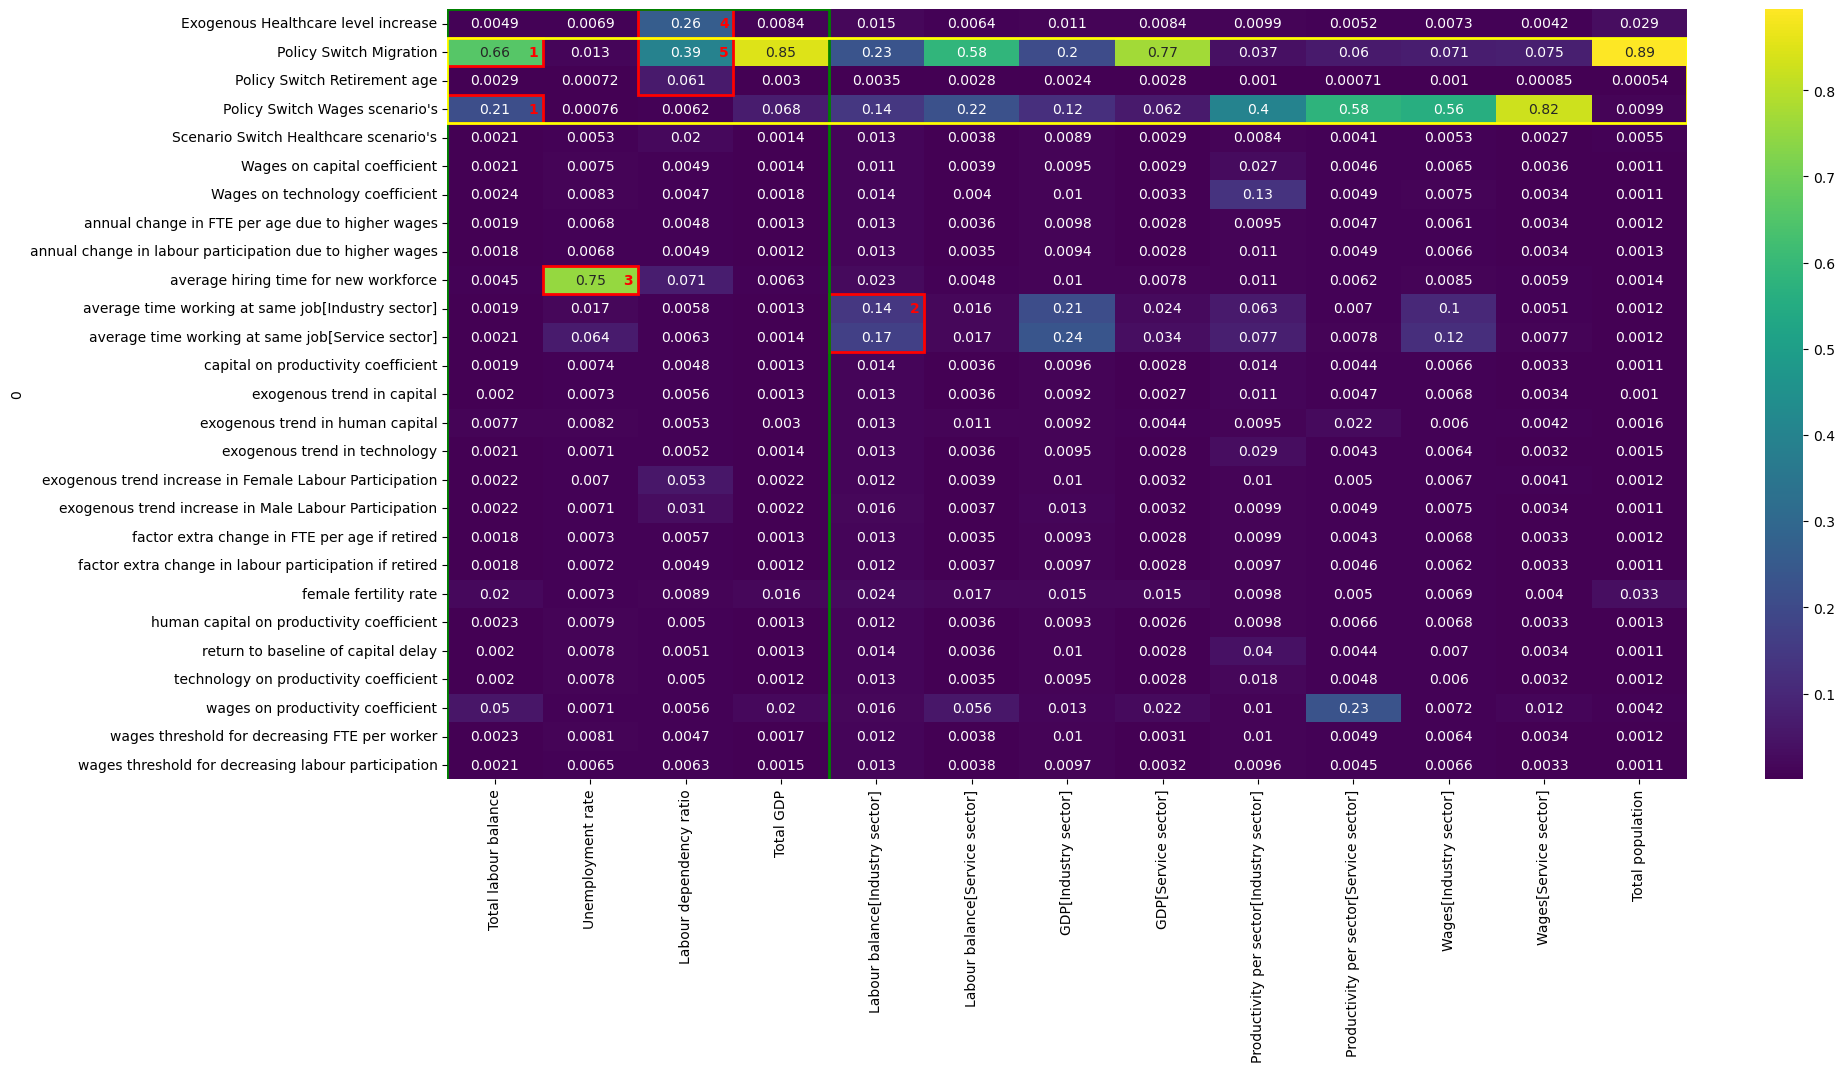

In [46]:
# Data setup
x = original_experiments
end_states = {k: v[:, -1] for k, v in original_outcomes.items()}
end_states.pop('TIME', None)
fs = feature_scoring.get_feature_scores_all(x, end_states)


# Create heatmap
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(fs, cmap="viridis", annot=True, ax=ax)

# Rectangles for individual cells (row, col, label)
single_cell_rects = [
    (1, 0,'1'),
    (3, 0,'1'),
    (9, 1, '3'),
    (0, 2, '4'), 
]

# Rectangles for groups of cells (row, col, width, height, label)
group_rects = [
    (10, 4, 1, 2, '2'),  
    (1, 2, 1, 2, '5'), 
]

# Rectangles for groups of cells (row, col, width, height, label)
group_rects2 = [  
    (0, 0, 4, 43, ''),  
]

# Rectangles for groups of cells (row, col, width, height, label)
group_rects3 = [  
    (1, 0, 13, 3, ''),  
]

# Draw single-cell rectangles
for row, col, label in single_cell_rects:
    rect = patches.Rectangle((col, row), 1, 1, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
    ax.text(col + 0.95, row + 0.5, label, color='red', ha='right', va='center', fontsize=10, fontweight='bold')

# Draw group rectangles
for row, col, width, height, label in group_rects:
    rect = patches.Rectangle((col, row), width, height, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
    ax.text(col + width - 0.05, row + height / 4, label, color='red',
            ha='right', va='center', fontsize=10, fontweight='bold')

# Draw group rectangles
for row, col, width, height, label in group_rects2:
    rect = patches.Rectangle((col, row), width, height, fill=False, edgecolor='green', linewidth=2)
    ax.add_patch(rect)
    ax.text(col + width - 0.05, row + height / 2, label, color='green',
            ha='right', va='center', fontsize=10, fontweight='bold')

# Draw group rectangles
for row, col, width, height, label in group_rects3:
    rect = patches.Rectangle((col, row), width, height, fill=False, edgecolor='yellow', linewidth=2)
    ax.add_patch(rect)
    ax.text(col + width - 0.05, row + height / 2, label, color='yellow',
            ha='right', va='center', fontsize=10, fontweight='bold')

plt.show()

C:\Users\31628\Documents\Studie\Python\Lib\site-packages\sklearn\utils\_array_api.py:392: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)
C:\Users\31628\Documents\Studie\Python\Lib\site-packages\sklearn\utils\_array_api.py:392: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)
C:\Users\31628\Documents\Studie\Python\Lib\site-packages\sklearn\utils\_array_api.py:392: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


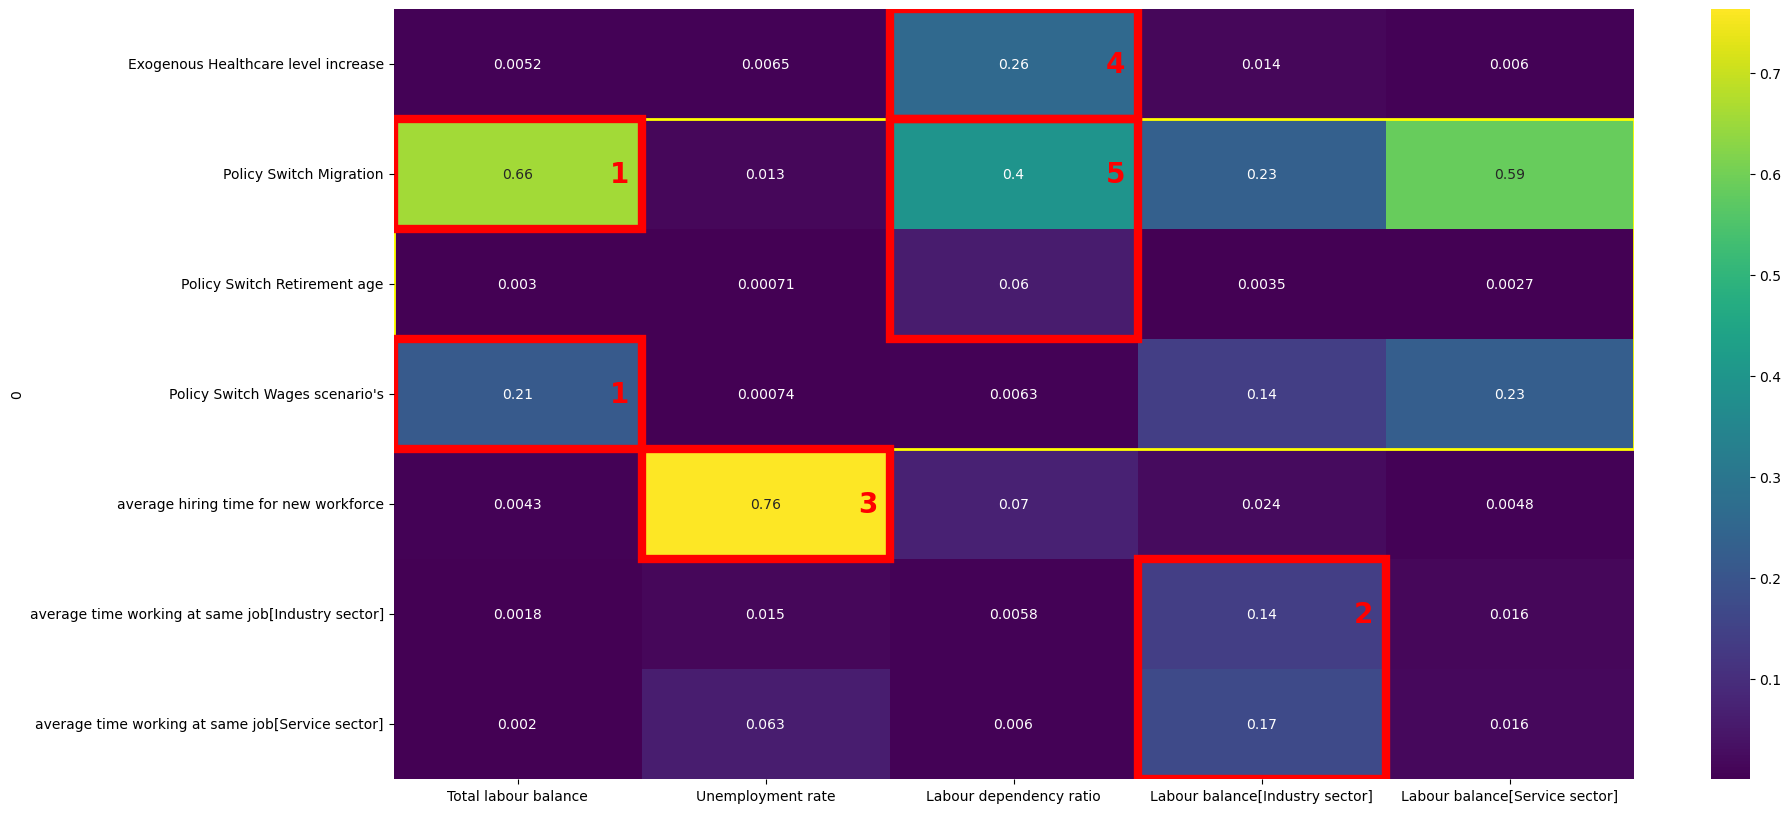

In [47]:
# Data setup
x = original_experiments
end_states = {k: v[:, -1] for k, v in original_outcomes.items()}
end_states.pop('TIME', None)
fs = feature_scoring.get_feature_scores_all(x, end_states)


# Define which columns and rows to include in the heatmap
rows_to_include = ['Exogenous Healthcare level increase', 'Policy Switch Migration', 'Policy Switch Retirement age', "Policy Switch Wages scenario's", 'average hiring time for new workforce', "average time working at same job[Industry sector]", "average time working at same job[Service sector]",] 
columns_to_include = ["Total labour balance", "Unemployment rate", "Labour dependency ratio", "Labour balance[Industry sector]", "Labour balance[Service sector]"] 
# Filter the DataFrame accordingly
fs = fs.loc[rows_to_include, columns_to_include]


# Create heatmap
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(fs, cmap="viridis", annot=True, ax=ax)

# Rectangles for individual cells (row, col, label)
single_cell_rects = [
    (1, 0,'1'),
    (3, 0,'1'),
    (4, 1, '3'),
    (0, 2, '4'), 
]

# Rectangles for groups of cells (row, col, width, height, label)
group_rects = [
    (5, 3, 1, 2, '2'),  
    (1, 2, 1, 2, '5'), 
]

# Rectangles for groups of cells (row, col, width, height, label)
group_rects2 = [  
    (0, 0, 3, 8, ''),  
]

# Rectangles for groups of cells (row, col, width, height, label)
group_rects3 = [  
    (1, 0, 5, 3, ''),  
]

# Draw group rectangles
#for row, col, width, height, label in group_rects2:
#    rect = patches.Rectangle((col, row), width, height, fill=False, edgecolor='green', linewidth=6)
#    ax.add_patch(rect)
#    ax.text(col + width - 0.05, row + height / 2, label, color='green',
#            ha='right', va='center', fontsize=10, fontweight='bold')

# Draw group rectangles
for row, col, width, height, label in group_rects3:
    rect = patches.Rectangle((col, row), width, height, fill=False, edgecolor='yellow', linewidth=2)
    ax.add_patch(rect)
    ax.text(col + width - 0.05, row + height / 2, label, color='yellow',
            ha='right', va='center', fontsize=10, fontweight='bold')

# Draw single-cell rectangles
for row, col, label in single_cell_rects:
    rect = patches.Rectangle((col, row), 1, 1, fill=False, edgecolor='red', linewidth=6)
    ax.add_patch(rect)
    ax.text(col + 0.95, row + 0.5, label, color='red', ha='right', va='center', fontsize=20, fontweight='bold')

# Draw group rectangles
for row, col, width, height, label in group_rects:
    rect = patches.Rectangle((col, row), width, height, fill=False, edgecolor='red', linewidth=6)
    ax.add_patch(rect)
    ax.text(col + width - 0.05, row + height / 4, label, color='red',
            ha='right', va='center', fontsize=20, fontweight='bold')

plt.show()


In [48]:
#original_outcomes
original_experiments

,Exogenous Healthcare level increase,Scenario Switch Healthcare scenario's,Wages on capital coefficient,Wages on technology coefficient,annual change in FTE per age due to higher wages,annual change in labour participation due to higher wages,average hiring time for new workforce,average time working at same job[Industry sector],average time working at same job[Service sector],capital on productivity coefficient,exogenous trend in capital,exogenous trend in human capital,exogenous trend in technology,exogenous trend increase in Female Labour Participation,exogenous trend increase in Male Labour Participation,factor extra change in FTE per age if retired,factor extra change in labour participation if retired,female fertility rate,human capital on productivity coefficient,return to baseline of capital delay,technology on productivity coefficient,wages on productivity coefficient,wages threshold for decreasing FTE per worker,wages threshold for decreasing labour participation,Policy Switch Migration,Policy Switch Retirement age,Policy Switch Wages scenario's
0,0.022476,1,13.621031,3.549753,0.000730,0.000863,0.694979,12.792868,6.938385,175.944727,0.006317,0.013395,0.008790,0.014804,0.014476,2.739679,2.414853,1.778821,3186.389798,1.773634,3089.077766,4.293021,5857.870160,5232.929448,1,0,1
1,0.025510,1,9.945813,4.413336,0.000513,0.000739,0.659040,9.109443,6.932481,162.636814,0.007080,0.014544,0.003473,0.018407,0.019266,2.141993,2.485851,1.585495,2726.292603,4.718865,3307.387608,2.104058,5910.725267,5619.918966,1,0,1
2,0.029494,1,11.628016,3.321010,0.000824,0.000613,0.190934,7.970197,7.445770,147.846021,0.006795,0.015626,0.008450,0.015533,0.010972,2.848692,2.809174,1.414017,3487.233769,4.647632,2810.715366,4.381467,6140.235832,7806.559701,1,0,1
3,0.024211,2,10.837561,1.176915,0.001176,0.001878,0.299704,11.091102,6.929200,131.448380,0.008687,0.012684,0.001815,0.007621,0.015688,1.991160,2.289741,1.791436,2711.544273,1.180504,2883.550444,2.501794,5106.091614,7695.191851,1,0,1
4,0.004764,1,5.486935,2.466649,0.001438,0.000854,0.564104,10.988994,11.670949,187.079173,0.005089,0.008162,0.002306,0.011364,0.006903,2.939299,1.846372,1.721569,2892.362884,4.532992,2722.751042,3.753200,5230.305316,5803.185375,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.024787,2,5.940658,3.251803,0.001162,0.001766,0.739570,10.410380,8.885075,191.646179,0.001638,0.014141,0.005957,0.009859,0.005113,2.522056,2.397527,1.441166,3043.258379,3.438890,2578.300044,2.668176,5745.675092,5556.598325,5,3,2
11996,0.014735,2,8.424136,3.033799,0.001246,0.001254,0.719209,9.547737,9.658534,134.251629,0.001579,0.005865,0.001732,0.012282,0.006705,2.543638,2.502651,1.309804,3207.029192,1.622884,3245.181971,3.826381,5006.399555,5989.975648,5,3,2
11997,0.009249,1,14.949462,3.456773,0.000707,0.001606,0.230053,14.299434,8.203137,132.134360,0.003857,0.012497,0.004658,0.011777,0.016630,1.621504,2.508938,1.589362,2610.895697,2.233222,3474.784675,3.920215,6660.187833,5275.389037,5,3,2
11998,0.032254,1,8.773969,2.724200,0.000504,0.000852,0.201966,12.172984,11.308907,169.171943,0.005803,0.019318,0.001996,0.019615,0.011311,1.666864,1.988781,1.569430,2671.308138,1.782746,2906.763940,2.692089,5743.816028,5643.256832,5,3,2


# PRIM Analysis

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\3152379327.py:45: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


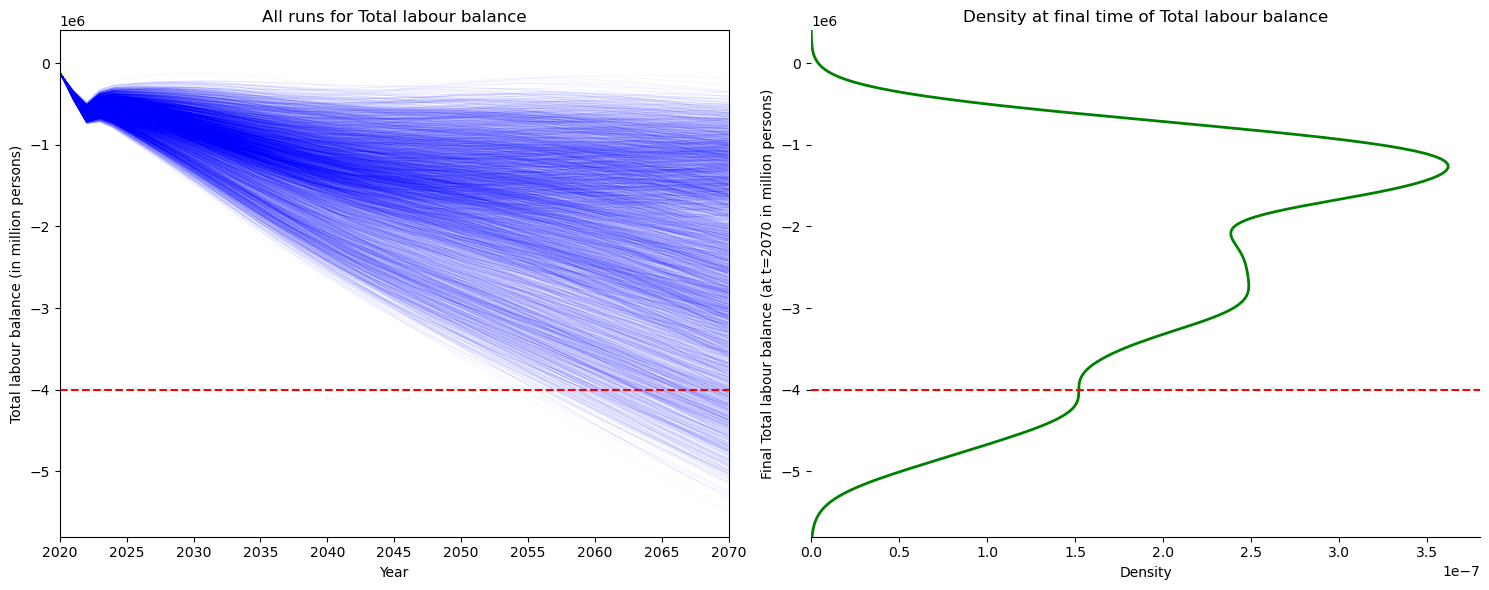

In [50]:
selected_kpi = "Total labour balance"
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
#axes[0].set_ylim(np.min(values), np.max(values))
axes[0].set_ylim(LB_y_limit_min, LB_y_limit_max) 
axes[0].axhline(y=-4000000, color='red', linestyle='--', linewidth=1.5, label='Threshold = -4M')


# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'All runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi + ' (in million persons)')

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi} (at t=2070 in million persons)' )
axes[1].set_ylim(LB_y_limit_min, LB_y_limit_max)
axes[1].axhline(y=-4000000, color='red', linestyle='--', linewidth=1.5, label='Threshold = -4M')


sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()

In [51]:
# Assume results is a tuple, e.g. (df, something_else)
df = original_experiments
other = original_outcomes

# Drop columns from df
cleaned_df = df

#cleaned_df = df.drop(columns=[
#    'scenario',
#    'policy',
#    'model',

#    'GDP Scenario 1 exogenous gap[Industry sector]',
#    'GDP Scenario 1 exogenous gap[Service sector]',
#    'Policy Switch Migration',
#    'Policy Switch Retirement age',
#    "Policy Switch Targeting ages in migration",
#    "Policy Switch Wages scenario's"

#])

# Create new tuple with modified df
cleaned_results = (cleaned_df, other)
#cleaned_results

# Advanced PRIM | Total labour balance

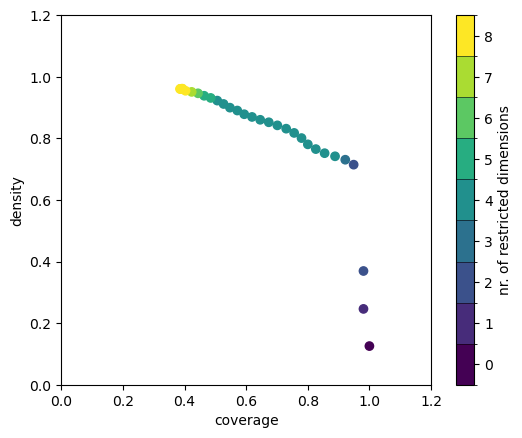

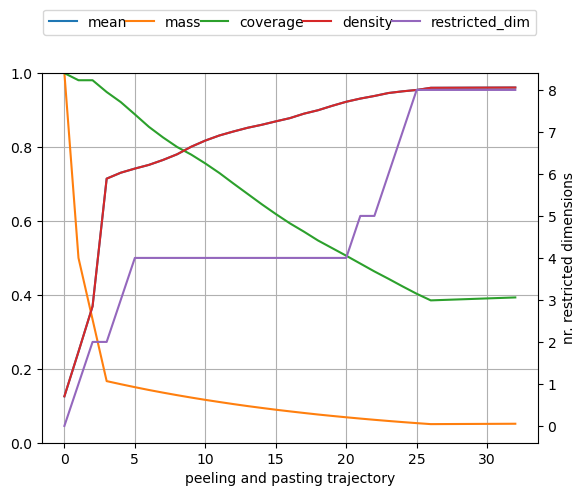

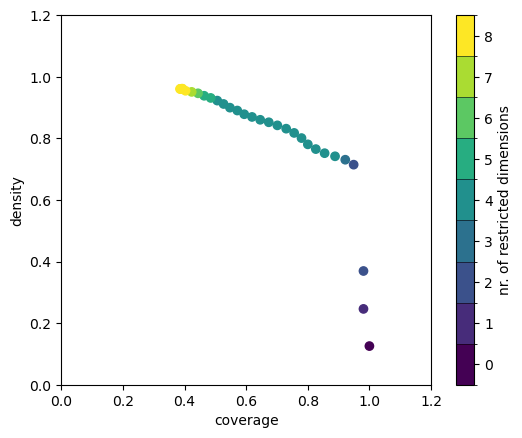

In [53]:
def classify(outcomes):
    ooi = outcomes["Total labour balance"]
    return ooi[:, -1] < -4000000

# perform prim on cleaned results tuple
prim_obj = prim.setup_prim(cleaned_results, classify, threshold=0.5, threshold_type=1)

box_1 = prim_obj.find_box()
box_1.show_ppt()
box_1.show_tradeoff()

C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{1}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]
C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{1}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]


coverage       0.779548
density        0.800819
id             9.000000
k           1174.000000
mass           0.122167
mean           0.800819
n           1466.000000
res_dim        4.000000
Name: 9, dtype: float64

                                      box 9                           \
                                        min       max       qp value   
wages on productivity coefficient   1.00166  4.079933            NaN   
female fertility rate              1.300049  1.774407            NaN   
Policy Switch Migration                 {1}       {1}   0.000000e+00   
Policy Switch Wages scenario's          {1}       {1}  1.494718e-205   

                                                 
                                       qp value  
wages on productivity coefficient  2.779306e-11  
female fertility rate              1.535856e-01  
Policy Switch Migration                     NaN  
Policy Switch Wages scenario's              NaN  

    coverage   density  id     k      mass      m

C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\scenario_discovery_util.py:929: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_boxes.loc[unc][index[i]] = values.values


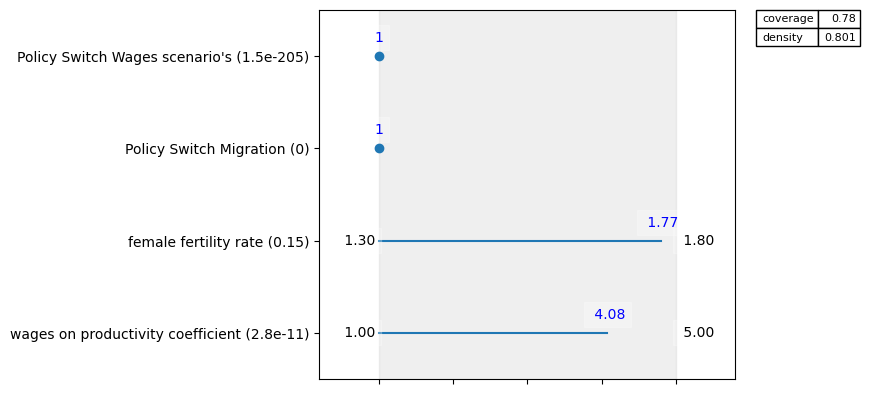

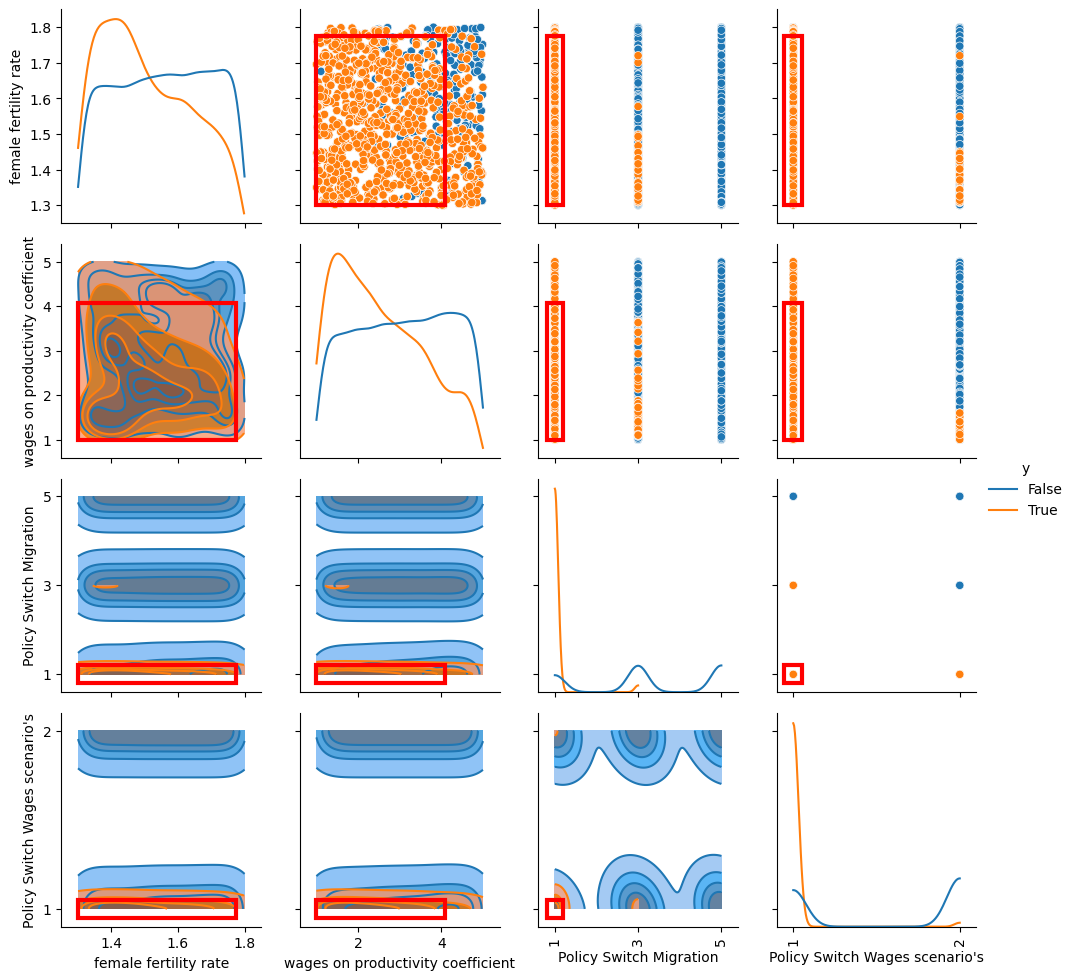

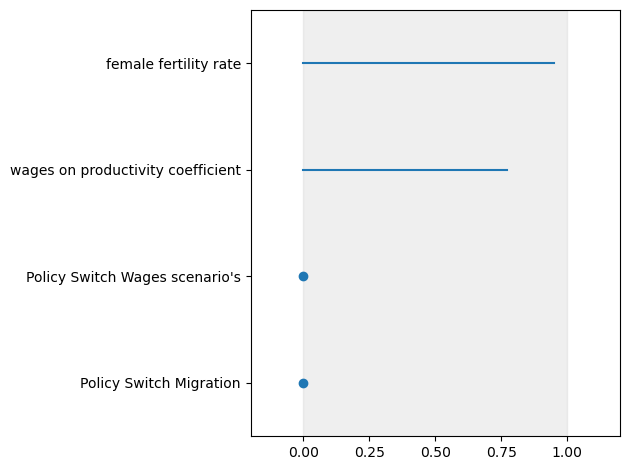

In [54]:
#Define point of interest based on above graph
poi = 9
box_1.inspect(poi, style="graph", boxlim_formatter="{: .2f}")
box_1.inspect(poi)
box_1.select(poi)
box_1.write_ppt_to_stdout()
box_1.show_pairs_scatter(poi)

# print prim to std_out
print(prim_obj.stats_to_dataframe())
print(prim_obj.boxes_to_dataframe())

# visualize
prim_obj.show_boxes([poi])
plt.show()

In [55]:
df_ex = original_experiments
subset_df_ex_Migration_policy_5 = df_ex[df_ex['Policy Switch Migration'] == 5]

In [56]:
# get the array indices of your subset
subset_idx = subset_df_ex_Migration_policy_5.index.values  # shape (4000,)

# build a new dict containing only those rows
outcomes_subset_Migration_policy_5 = {
    varname: data[subset_idx, :]
    for varname, data in original_outcomes.items()
}

# outcomes_subset_Migration_policy_5 now has exactly 4000 runs per variable


In [57]:
#subset_df_ex_Migration_policy_5
#outcomes_subset_Migration_policy_5

In [58]:
experiments = subset_df_ex_Migration_policy_5
outcomes = outcomes_subset_Migration_policy_5

cleaned_results = (experiments, outcomes)

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\1749758840.py:45: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


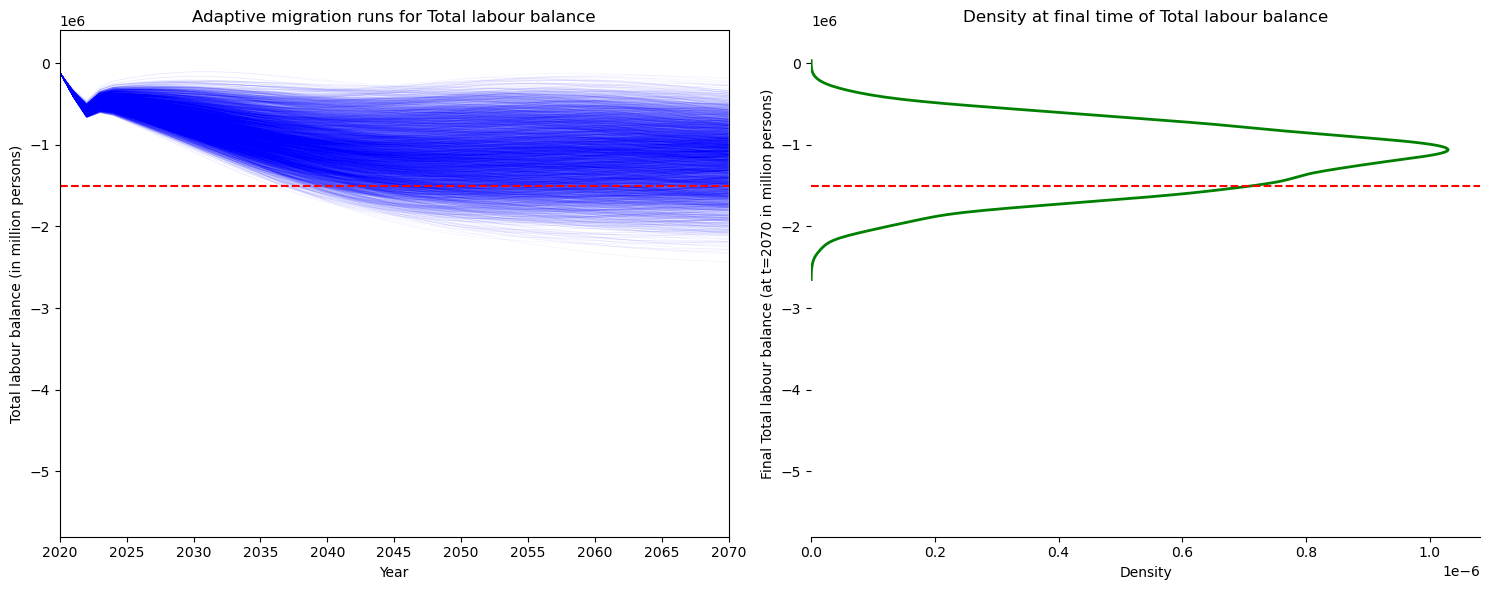

In [59]:
selected_kpi = "Total labour balance"
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
#axes[0].set_ylim(np.min(values), np.max(values))
axes[0].set_ylim(LB_y_limit_min, LB_y_limit_max) 
axes[0].axhline(y=-1500000, color='red', linestyle='--', linewidth=1.5, label='Threshold = -4M')


# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'Adaptive migration runs for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi + ' (in million persons)')

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi} (at t=2070 in million persons)' )
axes[1].set_ylim(LB_y_limit_min, LB_y_limit_max)
axes[1].axhline(y=-1500000, color='red', linestyle='--', linewidth=1.5, label='Threshold = -4M')


sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()

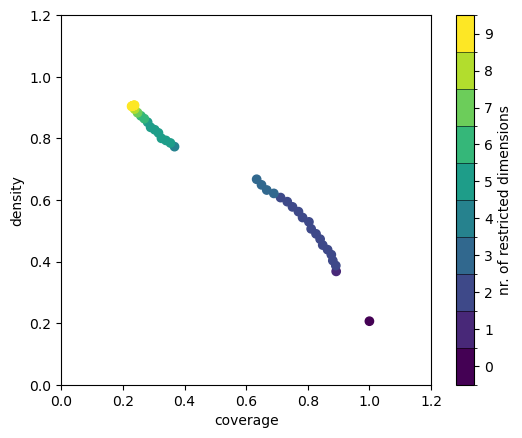

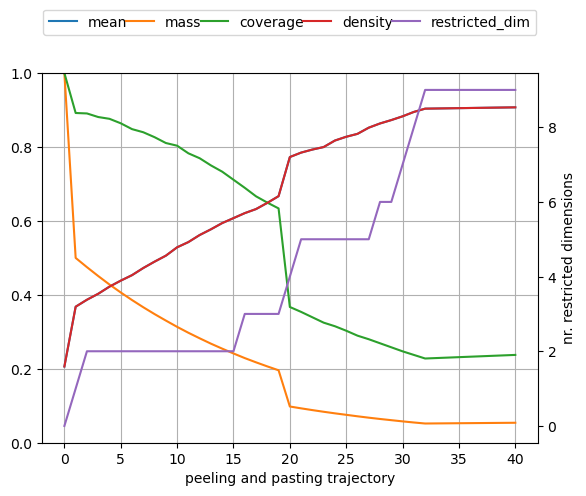

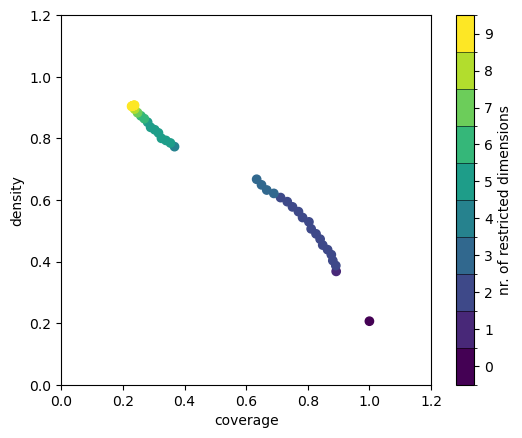

In [60]:
def classify(outcomes_subset_Migration_policy_5):
    ooi = outcomes_subset_Migration_policy_5["Total labour balance"]
    return ooi[:, -1] < -1500000

# numnber here?

# perform prim on cleaned results tuple
prim_obj = prim.setup_prim(cleaned_results, classify, threshold=0.5, threshold_type=1)

box_1 = prim_obj.find_box()
box_1.show_ppt()
box_1.show_tradeoff()

C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{1}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]
C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{1}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]


coverage      0.339394
density       0.793201
id           22.000000
k           280.000000
mass          0.088250
mean          0.793201
n           353.000000
res_dim       5.000000
Name: 22, dtype: float64

                                                box 22               \
                                                   min          max   
female fertility rate                         1.300049     1.496499   
human capital on productivity coefficient  2500.383531  3450.943276   
Policy Switch Wages scenario's                     {1}          {1}   
Policy Switch Retirement age                       {0}          {0}   
Exogenous Healthcare level increase           0.002104     0.039963   

                                                                       
                                               qp value      qp value  
female fertility rate                               NaN  1.780191e-35  
human capital on productivity coefficient           NaN  3.358934e-01  
Poli

C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\scenario_discovery_util.py:929: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_boxes.loc[unc][index[i]] = values.values


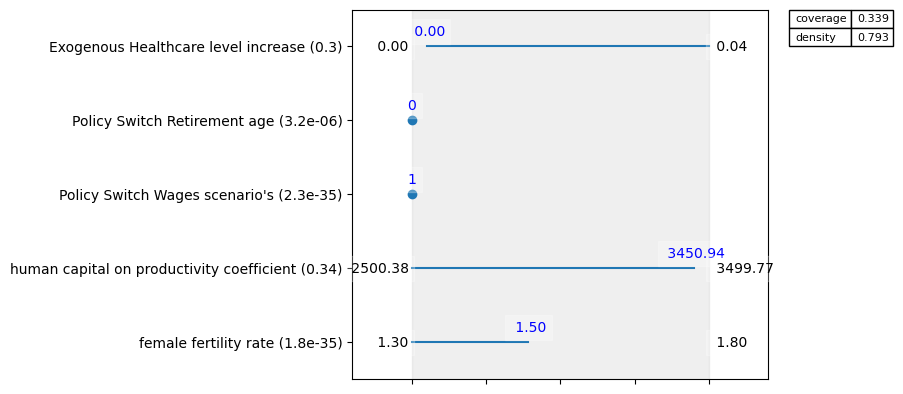

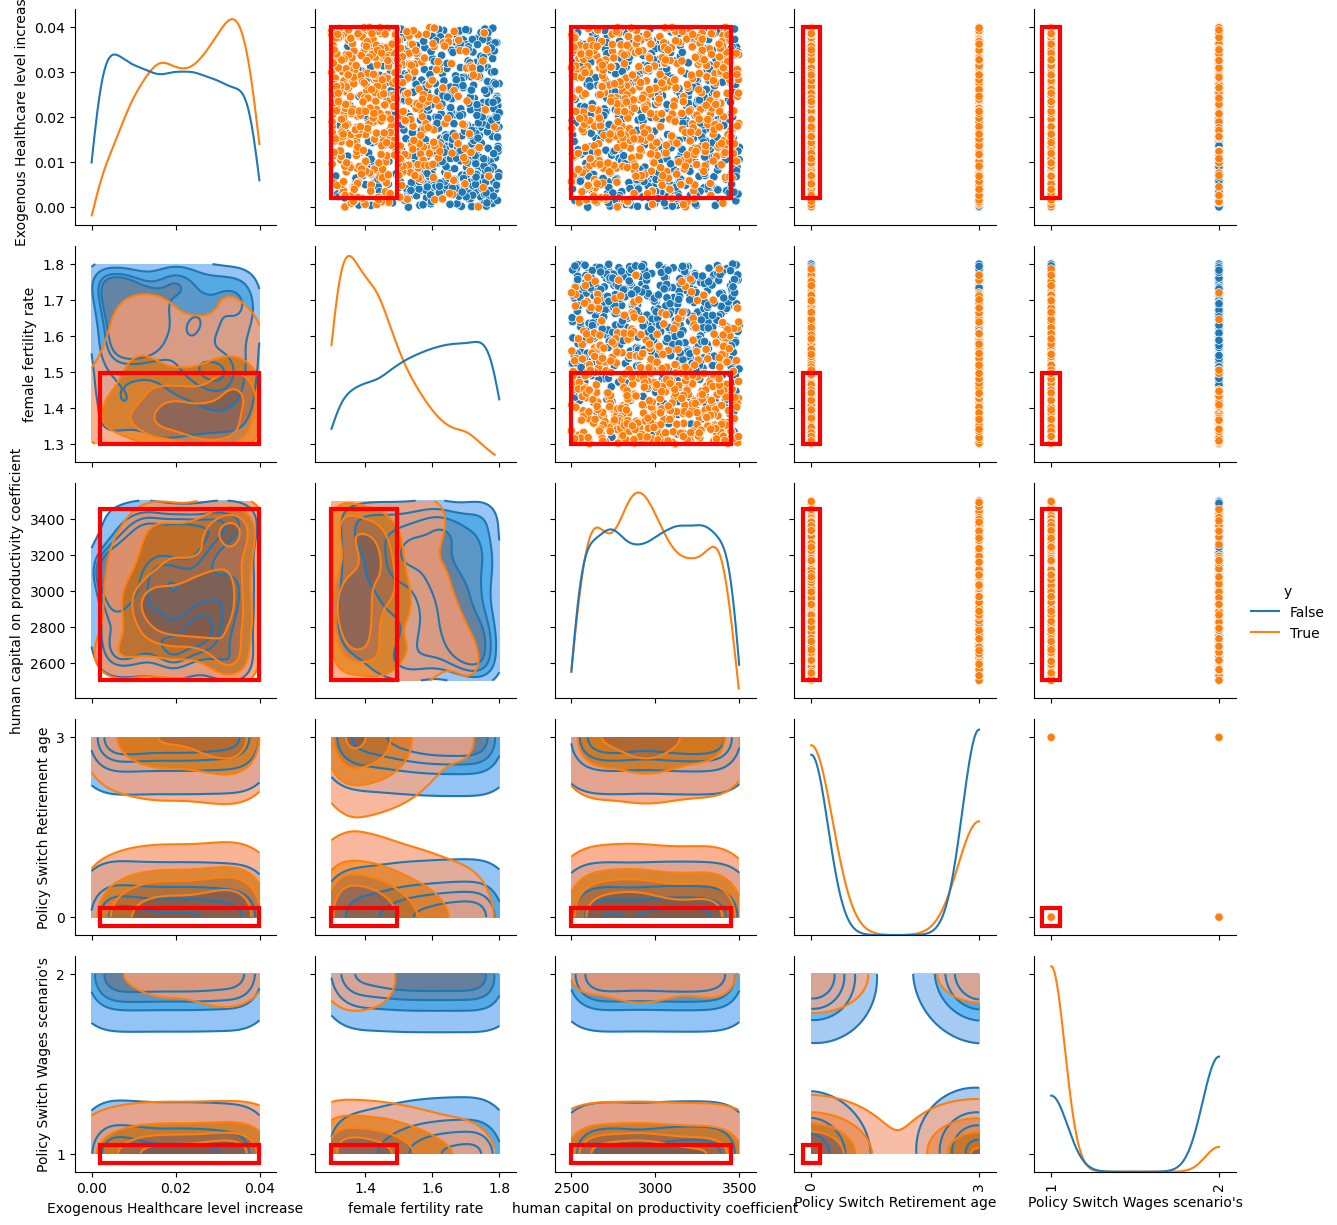

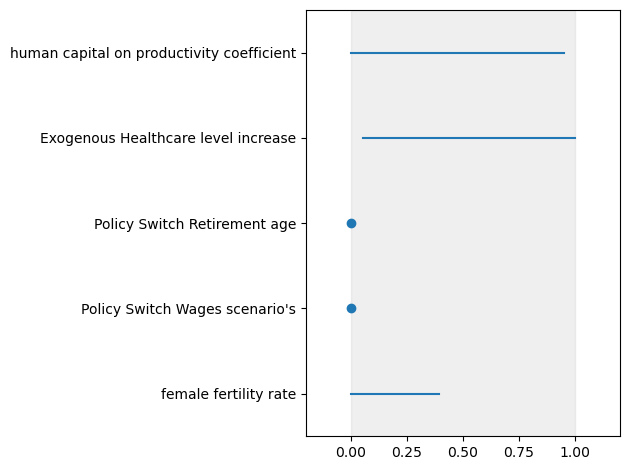

In [61]:
#Define point of interest based on above graph
poi = 22
box_1.inspect(poi, style="graph", boxlim_formatter="{: .2f}")
box_1.inspect(poi)
box_1.select(poi)
box_1.write_ppt_to_stdout()
box_1.show_pairs_scatter(poi)

# print prim to std_out
print(prim_obj.stats_to_dataframe())
print(prim_obj.boxes_to_dataframe())

# visualize
prim_obj.show_boxes([poi])
plt.show()

In [62]:
df_ex = original_experiments
subset_df_ex_Wages_policy_2 = df_ex[df_ex["Policy Switch Wages scenario's"] == 2]

In [63]:
# get the array indices of your subset
subset_idx = subset_df_ex_Wages_policy_2.index.values  # shape (6000,)

# build a new dict containing only those rows
outcomes_subset_Wages_policy_2 = {
    varname: data[subset_idx, :]
    for varname, data in original_outcomes.items()
}

# outcomes_subset_Wages_policy_2 now has exactly 6000 runs per variable

In [64]:
subset_df_ex_Wages_policy_2

,Exogenous Healthcare level increase,Scenario Switch Healthcare scenario's,Wages on capital coefficient,Wages on technology coefficient,annual change in FTE per age due to higher wages,annual change in labour participation due to higher wages,average hiring time for new workforce,average time working at same job[Industry sector],average time working at same job[Service sector],capital on productivity coefficient,exogenous trend in capital,exogenous trend in human capital,exogenous trend in technology,exogenous trend increase in Female Labour Participation,exogenous trend increase in Male Labour Participation,factor extra change in FTE per age if retired,factor extra change in labour participation if retired,female fertility rate,human capital on productivity coefficient,return to baseline of capital delay,technology on productivity coefficient,wages on productivity coefficient,wages threshold for decreasing FTE per worker,wages threshold for decreasing labour participation,Policy Switch Migration,Policy Switch Retirement age,Policy Switch Wages scenario's
1000,0.022476,1,13.621031,3.549753,0.000730,0.000863,0.694979,12.792868,6.938385,175.944727,0.006317,0.013395,0.008790,0.014804,0.014476,2.739679,2.414853,1.778821,3186.389798,1.773634,3089.077766,4.293021,5857.870160,5232.929448,1,0,2
1001,0.025510,1,9.945813,4.413336,0.000513,0.000739,0.659040,9.109443,6.932481,162.636814,0.007080,0.014544,0.003473,0.018407,0.019266,2.141993,2.485851,1.585495,2726.292603,4.718865,3307.387608,2.104058,5910.725267,5619.918966,1,0,2
1002,0.029494,1,11.628016,3.321010,0.000824,0.000613,0.190934,7.970197,7.445770,147.846021,0.006795,0.015626,0.008450,0.015533,0.010972,2.848692,2.809174,1.414017,3487.233769,4.647632,2810.715366,4.381467,6140.235832,7806.559701,1,0,2
1003,0.024211,2,10.837561,1.176915,0.001176,0.001878,0.299704,11.091102,6.929200,131.448380,0.008687,0.012684,0.001815,0.007621,0.015688,1.991160,2.289741,1.791436,2711.544273,1.180504,2883.550444,2.501794,5106.091614,7695.191851,1,0,2
1004,0.004764,1,5.486935,2.466649,0.001438,0.000854,0.564104,10.988994,11.670949,187.079173,0.005089,0.008162,0.002306,0.011364,0.006903,2.939299,1.846372,1.721569,2892.362884,4.532992,2722.751042,3.753200,5230.305316,5803.185375,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.024787,2,5.940658,3.251803,0.001162,0.001766,0.739570,10.410380,8.885075,191.646179,0.001638,0.014141,0.005957,0.009859,0.005113,2.522056,2.397527,1.441166,3043.258379,3.438890,2578.300044,2.668176,5745.675092,5556.598325,5,3,2
11996,0.014735,2,8.424136,3.033799,0.001246,0.001254,0.719209,9.547737,9.658534,134.251629,0.001579,0.005865,0.001732,0.012282,0.006705,2.543638,2.502651,1.309804,3207.029192,1.622884,3245.181971,3.826381,5006.399555,5989.975648,5,3,2
11997,0.009249,1,14.949462,3.456773,0.000707,0.001606,0.230053,14.299434,8.203137,132.134360,0.003857,0.012497,0.004658,0.011777,0.016630,1.621504,2.508938,1.589362,2610.895697,2.233222,3474.784675,3.920215,6660.187833,5275.389037,5,3,2
11998,0.032254,1,8.773969,2.724200,0.000504,0.000852,0.201966,12.172984,11.308907,169.171943,0.005803,0.019318,0.001996,0.019615,0.011311,1.666864,1.988781,1.569430,2671.308138,1.782746,2906.763940,2.692089,5743.816028,5643.256832,5,3,2


In [65]:
experiments = subset_df_ex_Wages_policy_2
outcomes = outcomes_subset_Wages_policy_2

cleaned_results = (experiments, outcomes)

C:\Users\31628\AppData\Local\Temp\ipykernel_11672\3914125336.py:45: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)


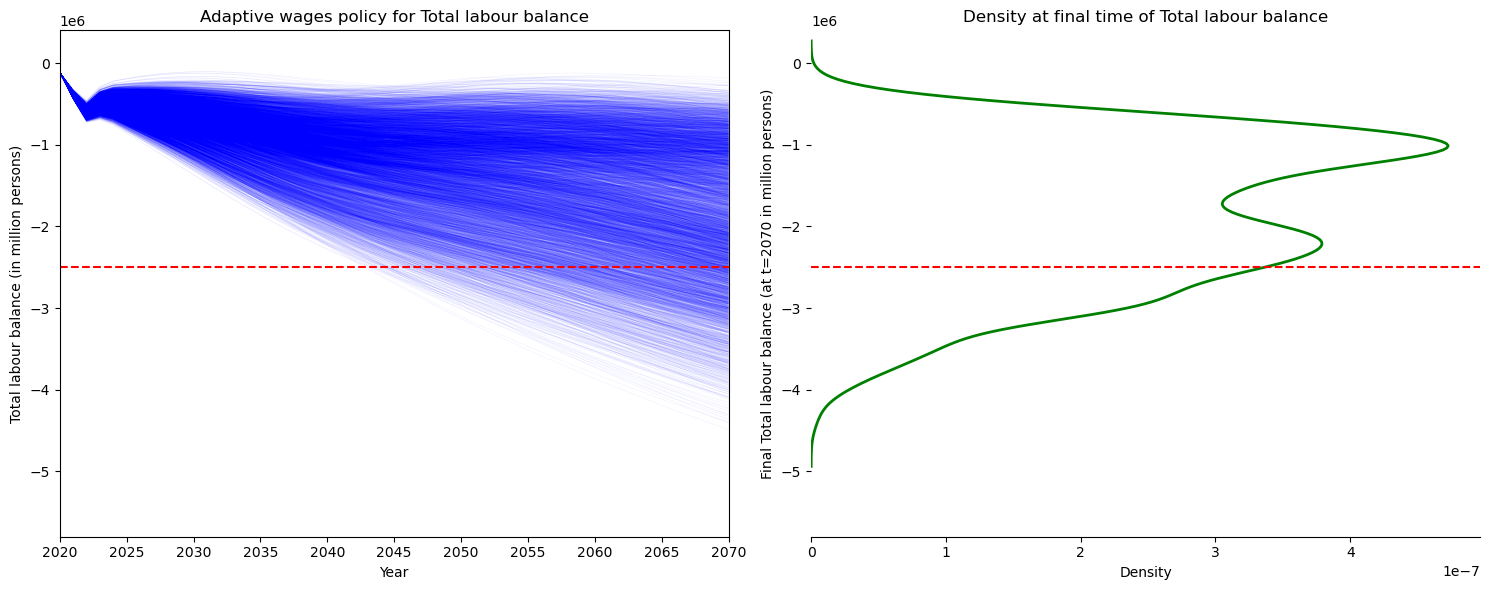

In [66]:
selected_kpi = "Total labour balance"
values = outcomes[selected_kpi]
num_runs, num_steps = values.shape
final_points = values[:, -1]  # final timestep values for all runs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------
# Left panel: plot all runs using LineCollection for speed

segments = [np.column_stack((range(num_steps), values[i])) for i in range(num_runs)]
line_collection = LineCollection(segments, colors='blue', linewidths=0.5, alpha=0.05)
axes[0].add_collection(line_collection)
axes[0].set_xlim(0, num_steps - 1)
#axes[0].set_ylim(np.min(values), np.max(values))
axes[0].set_ylim(LB_y_limit_min, LB_y_limit_max) 
axes[0].axhline(y=-2500000, color='red', linestyle='--', linewidth=1.5, label='Threshold = -4M')


# -----------------------
# Map timesteps linearly to years from 2020 to 2070
start_year = 2020
end_year = 2070
total_years = end_year - start_year

# Compute how many years per timestep
year_per_step = total_years / (num_steps - 1)

# Define the desired tick labels: every 5 years from 2020 to 2070
year_ticks = np.arange(start_year, end_year + 1, 5)

# Convert those year labels back to their corresponding timestep positions
tick_positions = (year_ticks - start_year) / year_per_step

axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(year_ticks)

axes[0].set_title(f'Adaptive wages policy for {selected_kpi}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel(selected_kpi + ' (in million persons)')

# -----------------------
# Right panel: KDE of final values

sns.kdeplot(final_points, ax=axes[1], color='green', vertical=True, linewidth=2)
axes[1].set_title(f'Density at final time of {selected_kpi}')
axes[1].set_xlabel('Density')
axes[1].set_ylabel(f'Final {selected_kpi} (at t=2070 in million persons)' )
axes[1].set_ylim(LB_y_limit_min, LB_y_limit_max)
axes[1].axhline(y=-2500000, color='red', linestyle='--', linewidth=1.5, label='Threshold = -4M')


sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()

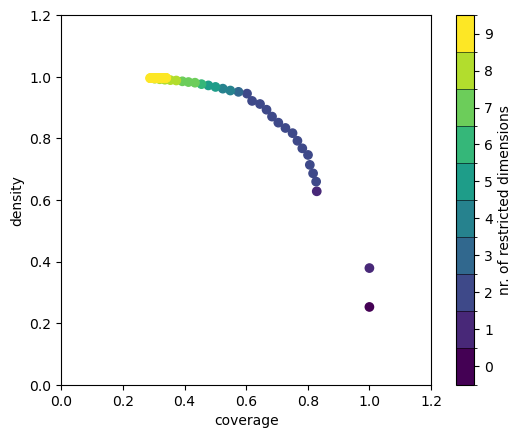

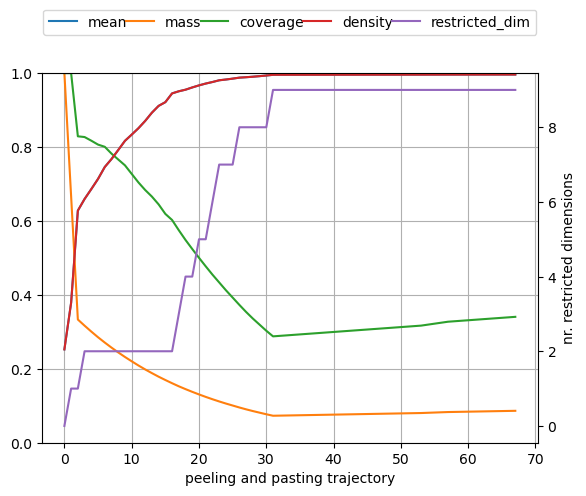

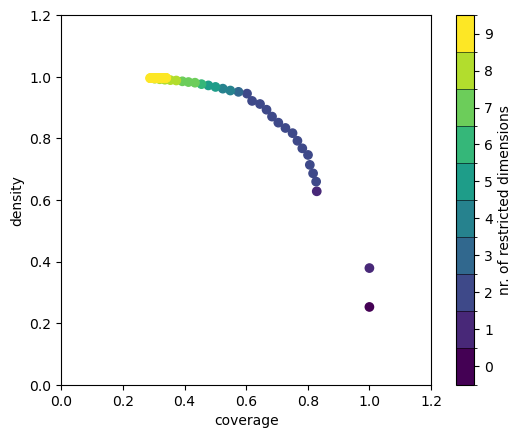

In [67]:
def classify(outcomes_subset_Migration_policy_5):
    ooi = outcomes_subset_Migration_policy_5["Total labour balance"]
    return ooi[:, -1] < -2500000

# numnber here?

# perform prim on cleaned results tuple
prim_obj = prim.setup_prim(cleaned_results, classify, threshold=0.5, threshold_type=1)

box_1 = prim_obj.find_box()
box_1.show_ppt()
box_1.show_tradeoff()

C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{1}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]
C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{1}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]


coverage       0.766337
density        0.791951
id             8.000000
k           1161.000000
mass           0.244333
mean           0.791951
n           1466.000000
res_dim        2.000000
Name: 8, dtype: float64

                                     box 8                           \
                                       min       max       qp value   
wages on productivity coefficient  1.00166  3.931355            NaN   
Policy Switch Migration                {1}       {1}  2.397183e-298   

                                                 
                                       qp value  
wages on productivity coefficient  4.784977e-42  
Policy Switch Migration                     NaN  

    coverage   density  id     k      mass      mean     n  res_dim
0   1.000000  0.252500   0  1515  1.000000  0.252500  6000        0
1   1.000000  0.378750   1  1515  0.666667  0.378750  4000        1
2   0.829043  0.628000   2  1256  0.333333  0.628000  2000        1
3   0.827063  0.659474   

C:\Users\31628\Documents\Studie\Python\Lib\site-packages\ema_workbench\analysis\scenario_discovery_util.py:929: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_boxes.loc[unc][index[i]] = values.values


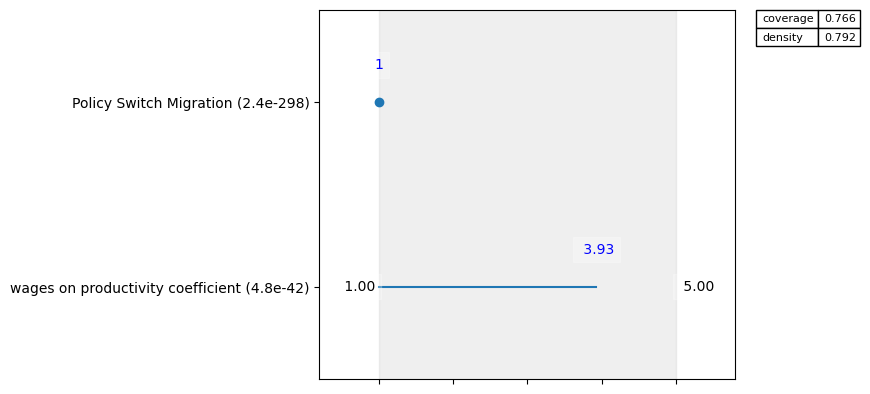

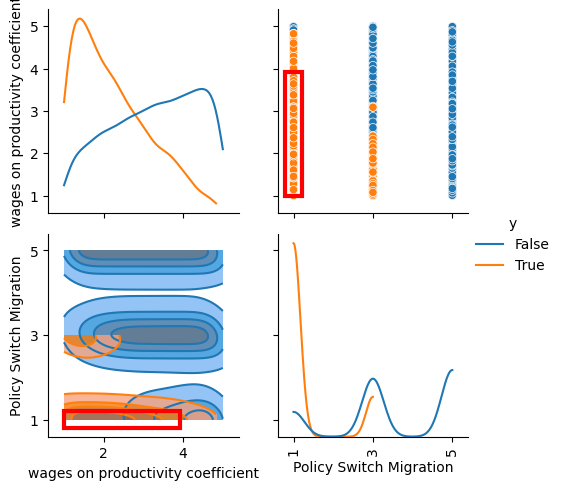

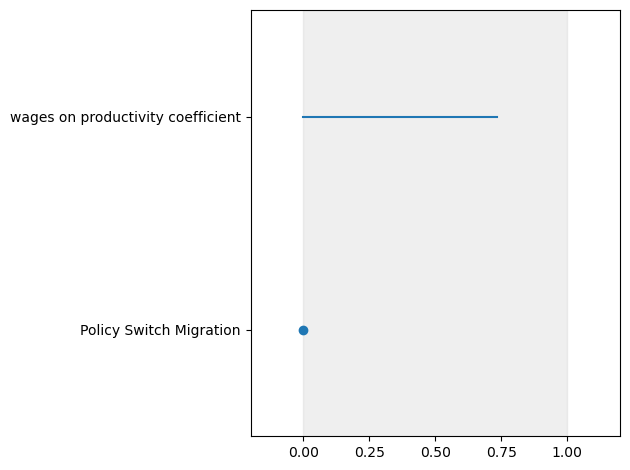

In [68]:
#Define point of interest based on above graph
poi = 8
box_1.inspect(poi, style="graph", boxlim_formatter="{: .2f}")
box_1.inspect(poi)
box_1.select(poi)
box_1.write_ppt_to_stdout()
box_1.show_pairs_scatter(poi)

# print prim to std_out
print(prim_obj.stats_to_dataframe())
print(prim_obj.boxes_to_dataframe())

# visualize
prim_obj.show_boxes([poi])
plt.show()